In [1]:
using Pkg
Pkg.activate(".")

  Activating project at `~/Documents/MacbookPro/TDVP Expansion`


In [2]:
Pkg.add(["ITensors","ITensorMPS","Compat","OrdinaryDiffEqTsit5",
        "Graphs","NamedGraphs","SpecialFunctions",
        "Observers","KrylovKit","Plots","DataFrames","HDF5"])
Pkg.instantiate()

     Project No packages added to or removed from `~/Documents/MacbookPro/TDVP Expansion/Project.toml`
    Manifest No packages added to or removed from `~/Documents/MacbookPro/TDVP Expansion/Manifest.toml`


In [3]:
using ITensors
using ITensorMPS
using KrylovKit: exponentiate
using OrdinaryDiffEqTsit5: ODEProblem, Tsit5, solve
using Graphs, NamedGraphs
using SpecialFunctions: erf
using Observers
using Plots
using DataFrames
using HDF5

In [4]:
# ── TimeDependentSum ──────────────────────────────────────────────────────────
# Ported from archived ITensorTDVP.jl. Interface methods are extended into the
# ITensorMPS namespace so alternating_update picks them up over the identity fallback.

struct TimeDependentSum{C,T}
    coefficients::C
    terms::T
end
coefficients(e::TimeDependentSum) = e.coefficients
terms(e::TimeDependentSum) = e.terms
Base.copy(e::TimeDependentSum) = TimeDependentSum(coefficients(e), copy.(terms(e)))
function Base.:*(c::Number, e::TimeDependentSum)
    return TimeDependentSum(map(f -> (t -> c * f(t)), coefficients(e)), terms(e))
end
Base.:*(e::TimeDependentSum, c::Number) = c * e
(e::TimeDependentSum)(t::Number) = ScaledSum(map(f -> f(t), coefficients(e)), terms(e))

ITensorMPS.reduced_operator(op::TimeDependentSum) =
    TimeDependentSum(coefficients(op), ITensorMPS.reduced_operator.(terms(op)))
ITensorMPS.set_nsite!(op::TimeDependentSum, nsite) =
    (foreach(t -> ITensorMPS.set_nsite!(t, nsite), terms(op)); op)
ITensorMPS.position!(op::TimeDependentSum, state, pos) =
    (foreach(t -> ITensorMPS.position!(t, state, pos), terms(op)); op)

# ── ScaledSum ─────────────────────────────────────────────────────────────────

struct ScaledSum{C,T}
    coefficients::C
    terms::T
end
coefficients(e::ScaledSum) = e.coefficients
terms(e::ScaledSum) = e.terms

function _apply(e::ScaledSum, x)
    return mapreduce(+, zip(coefficients(e), terms(e))) do (c, H)
        c * H(x)
    end
end
(e::ScaledSum)(x) = _apply(e, x)
(e::ScaledSum)(x::ITensor) = permute(_apply(e, x), inds(x))

# ── Qudit operators ───────────────────────────────────────────────────────────

function ITensors.op(::OpName"ad", ::SiteType"Qudit", d::Int)
    m = zeros(d, d)
    for i in 1:d-1; m[i+1, i] = √i; end
    return m
end
function ITensors.op(::OpName"a", ::SiteType"Qudit", d::Int)
    m = zeros(d, d)
    for i in 1:d-1; m[i, i+1] = √i; end
    return m
end
function ITensors.op(::OpName"adadaa", ::SiteType"Qudit", d::Int)
    m = zeros(d, d)
    for i in 1:d; m[i, i] = Float64((i-1)*(i-2)); end
    return m
end
function ITensors.op(::OpName"n", ::SiteType"Qudit", d::Int)
    m = zeros(d, d)
    for i in 1:d; m[i, i] = Float64(i-1); end
    return m
end
function ITensors.op(::OpName"nd", ::SiteType"Qudit", d::Int)
    m = zeros(d, d); m[3, 3] = 1.0; return m
end

In [5]:
function Grid1D(Lx::Int; d=3, Pn=Lx)
    Nsites = Lx 
    sites = siteinds("Qudit", Nsites; dim=d, conserve_number=true, qnname_number="n")
    bond = Index(QN("n", 0) => 1, tags="Link")
    bonds = [settags(bond, "Link"*string(i)) for i in 1:Nsites]
    ψ = MPS(sites)
    ψ[1] = onehot(sites[1] => 2, bonds[1] => 1); Pn -= 1
    for i in 2:Nsites-1
        ψ[i] = Pn == 0 ? onehot(sites[i] => 1, dag(bonds[i-1]) => 1, bonds[i] => 1) :
                         onehot(sites[i] => 2, dag(bonds[i-1]) => 1, bonds[i] => 1)
        Pn != 0 && (Pn -= 1)
    end
    ψ[Nsites] = Pn == 0 ? onehot(sites[Nsites] => 1, dag(bonds[Nsites-1]) => 1) :
                           onehot(sites[Nsites] => 2, dag(bonds[Nsites-1]) => 1)
    return ψ, sites
end

Grid1D (generic function with 1 method)

In [6]:
ψ1,sites1=Grid1D(10;d=3,Pn=5);

In [7]:
op(sites1[1],"ad")

ITensor ord=2
(dim=3|id=356|"Qudit,Site,n=1")' <Out>
 1: QN("n",0) => 1
 2: QN("n",1) => 1
 3: QN("n",2) => 1
(dim=3|id=356|"Qudit,Site,n=1") <In>
 1: QN("n",0) => 1
 2: QN("n",1) => 1
 3: QN("n",2) => 1
NDTensors.BlockSparse{Float64, Vector{Float64}, 2}

In [8]:
function BoseHubbardModel(t, U, len;V=nothing)
    H = OpSum()
    if !iszero(t)
        H += -t, "n", 1
        for j in 1:len-1
            H += -t, "ad", j, "a", j+1
            H += -t, "ad", j+1, "a", j
        end
    end
    for vertex in 1:len
        V!=nothing && !iszero(V[vertex]) && (H += (V[vertex], "n", vertex))
        !iszero(U) && (H += (U/2, "adadaa", vertex))
    end
    return H
end

function Hopping(len)
    H = OpSum()
    H += -1, "n", 1
    for j in 1:len-1
            H +=  -1,"ad", j, "a", j+1
            H +=  -1,"ad", j+1, "a", j
    end
    return H
end

function Interactions(len)
    H = OpSum()
    for vertex in 1:len
        H += 1/2, "adadaa", vertex
    end
    return H
end


Interactions (generic function with 1 method)

In [9]:
BoseHubbardModel(1, 10, 5)

sum(
  -1.0 n(1,)
  -1.0 ad(1,) a(2,)
  -1.0 ad(2,) a(1,)
  -1.0 ad(2,) a(3,)
  -1.0 ad(3,) a(2,)
  -1.0 ad(3,) a(4,)
  -1.0 ad(4,) a(3,)
  -1.0 ad(4,) a(5,)
  -1.0 ad(5,) a(4,)
  5.0 adadaa(1,)
  5.0 adadaa(2,)
  5.0 adadaa(3,)
  5.0 adadaa(4,)
  5.0 adadaa(5,)
)

In [10]:
BoseHubbardModel(1, 2, 5,V=[1,1,-1,-1,-1])

sum(
  -1.0 n(1,)
  -1.0 ad(1,) a(2,)
  -1.0 ad(2,) a(1,)
  -1.0 ad(2,) a(3,)
  -1.0 ad(3,) a(2,)
  -1.0 ad(3,) a(4,)
  -1.0 ad(4,) a(3,)
  -1.0 ad(4,) a(5,)
  -1.0 ad(5,) a(4,)
  1.0 n(1,)
  1.0 adadaa(1,)
  1.0 n(2,)
  1.0 adadaa(2,)
  -1.0 n(3,)
  1.0 adadaa(3,)
  -1.0 n(4,)
  1.0 adadaa(4,)
  -1.0 n(5,)
  1.0 adadaa(5,)
)

In [11]:
# ── Updaters ──────────────────────────────────────────────────────────────────

function ode_updater(operator, init; internal_kwargs, alg=Tsit5(), kwargs...)
    (; current_time, time_step) = (; current_time=zero(Bool), internal_kwargs...)
    time_span = typeof(time_step).((current_time, current_time + time_step))
    init_vec, to_itensor = to_vec(init)
    f(x::ITensor, ::Any, t) = operator(t)(x)
    f(v::AbstractArray, p, t) = to_vec(f(to_itensor(v), p, t))[1]
    sol = solve(ODEProblem(f, init_vec, time_span), alg; kwargs...)
    return to_itensor(sol.u[end]), (;)
end

function krylov_updater(operator, init; internal_kwargs, kwargs...)
    (; current_time, time_step) = (; current_time=zero(Bool), internal_kwargs...)
    state, info = exponentiate(operator(current_time), time_step, init; kwargs...)
    return state, (; info)
end

krylov_updater (generic function with 1 method)

In [12]:
siteind(ψ1,2)

(dim=3|id=600|"Qudit,Site,n=2") <Out>
 1: QN("n",0) => 1
 2: QN("n",1) => 1
 3: QN("n",2) => 1

In [13]:
for s in siteind(ψ1,2)
    println(s)
end

(dim=3|id=600|"Qudit,Site,n=2") <Out>
 1: QN("n",0) => 1
 2: QN("n",1) => 1
 3: QN("n",2) => 1 => 1
(dim=3|id=600|"Qudit,Site,n=2") <Out>
 1: QN("n",0) => 1
 2: QN("n",1) => 1
 3: QN("n",2) => 1 => 2
(dim=3|id=600|"Qudit,Site,n=2") <Out>
 1: QN("n",0) => 1
 2: QN("n",1) => 1
 3: QN("n",2) => 1 => 3


In [14]:
maximum(dim(s) for s in siteinds(ψ1))

3

In [15]:
ITensorMPS.scalartype(ψ1)

Float64

In [16]:
zeros(Float64,5,3)

5×3 Matrix{Float64}:
 0.0  0.0  0.0
 0.0  0.0  0.0
 0.0  0.0  0.0
 0.0  0.0  0.0
 0.0  0.0  0.0

In [17]:
orthogonalize!(ψ1,1);

In [18]:
si1=siteind(ψ1,1)

(dim=3|id=356|"Qudit,Site,n=1") <Out>
 1: QN("n",0) => 1
 2: QN("n",1) => 1
 3: QN("n",2) => 1

In [19]:
ψ1[1]*dag(onehot(si1=>1))

ITensor ord=1
(dim=1|id=290|"Link1") <Out>
 1: QN("n",4) => 1
NDTensors.BlockSparse{Float64, Vector{Float64}, 1}

In [20]:
for (j,s) in enumerate(si1)
    A1=ψ1[1]*dag(onehot(s))
    val=only(A1*dag(A1))
    val=norm(A1)^2
    println(j," ",val)
end

1 0.0
2 1.0
3 0.0


In [21]:
function probs(psi::MPS; sites = 1:length(psi))
    psi = copy(psi)
    N = length(psi)
    ElT = ITensorMPS.scalartype(psi)
    s = siteinds(psi)

    site_range = (sites isa AbstractRange) ? sites : collect(sites)
    Ns = length(site_range)
    start_site = first(site_range)

    psi = orthogonalize(psi, start_site)
    norm2_psi = norm(psi)^2
    iszero(norm2_psi) && error("MPS has zero norm in function `probs`")

    maxdim = maximum(dim(s) for s in siteinds(psi))
    result= zeros(Float64,Ns,maxdim)
    
    for (entry, j) in enumerate(site_range)
        psi = orthogonalize(psi, j)
        ind=siteind(psi,j)
        A=psi[j]
        for (n,sv) in enumerate(ind)
            pA=(A*dag(onehot(sv)))
            prob=norm(pA)^2/norm2_psi
            result[entry,n]=prob
        end
    end

    return result
end
            
            
        

probs (generic function with 1 method)

In [22]:
probs(ψ1)

10×3 Matrix{Float64}:
 0.0  1.0  0.0
 0.0  1.0  0.0
 0.0  1.0  0.0
 0.0  1.0  0.0
 0.0  1.0  0.0
 1.0  0.0  0.0
 1.0  0.0  0.0
 1.0  0.0  0.0
 1.0  0.0  0.0
 1.0  0.0  0.0

In [23]:
expect(ψ1,"n")

10-element Vector{Float64}:
 1.0
 1.0
 1.0
 1.0
 1.0
 0.0
 0.0
 0.0
 0.0
 0.0

In [24]:
p_observer() = observer(
    "steps"  => (; sweep)        -> sweep,
    "times"  => (; current_time) -> current_time,
    "probs" => (; state)        -> probs(state),
)

p_observer (generic function with 1 method)

In [25]:
p_observer()

Row,steps,times,probs
,Union{},Union{},Union{}


# Finding Ground State

In [26]:
mutable struct EnergyObserver <: AbstractObserver
   energy_tol::Float64
   last_energy::Float64
    sweep::Int64
    energylist :: Vector{Float64}

   EnergyObserver(energy_tol=0.0) = new(energy_tol,1000.0,0,[])
end

function ITensorMPS.checkdone!(o::EnergyObserver;kwargs...)
  sw = kwargs[:sweep]
  energy = kwargs[:energy]
  out=kwargs[:outputlevel]
  o.sweep= sw
  push!(o.energylist,energy)
  if abs(energy-o.last_energy)/abs(energy) < o.energy_tol
    if out>0
        println("Stopping DMRG after sweep $sw")
    end
    return true
  end
  # Otherwise, update last_energy and keep going
  o.last_energy = energy
  return false
end

In [27]:
function findgs(num,trap;t=1,U=0,maxn=2,etol=1e-8,
        dmrgopts=(nsweeps=100,maxdim=100,cutoff=1E-6,outputlevel=0))
    d=maxn+1
    Lx=length(trap)
    ψ,sites=Grid1D(Lx; d, Pn=num)
    Hop=BoseHubbardModel(t, U, Lx,V=trap)
    HMPO=MPO(Hop,sites)
    observer=EnergyObserver(etol)
    E,ψ=dmrg(HMPO,ψ;dmrgopts...,observer)
    return (;ψ,E,observer)
end

findgs (generic function with 1 method)

In [28]:
function well(numsites;V,L,s)
    if s==0
        return [j>L ? V : 0 for j in 1:numsites]
    end
    return [(V/2)*(1+tanh((j-L)/s)) for j in 1:numsites]
end

well (generic function with 1 method)

In [29]:
well(10;V=5,L=4,s=0.01)

10-element Vector{Float64}:
 0.0
 0.0
 0.0
 2.5
 5.0
 5.0
 5.0
 5.0
 5.0
 5.0

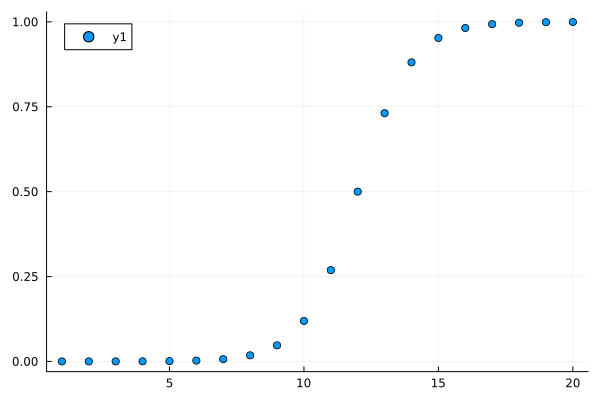

In [30]:
scatter(well(20;V=1,L=12,s=2))

In [31]:
@time gs1=findgs(10,well(20;V=20,L=12,s=2);t=1,U=10,maxn=2,
    dmrgopts=(nsweeps=50,maxdim=100,cutoff=1E-6,outputlevel=1))

After sweep 1 energy=-0.9134949823046199  maxlinkdim=8 maxerr=8.78E-07 time=12.888
After sweep 2 energy=-0.9135754788895412  maxlinkdim=8 maxerr=9.93E-07 time=0.278
After sweep 3 energy=-0.9135754788307171  maxlinkdim=8 maxerr=9.93E-07 time=0.098
Stopping DMRG after sweep 3
 23.723334 seconds (93.02 M allocations: 4.639 GiB, 2.34% gc time, 99.08% compilation time)


(ψ = MPS(20), E = -0.9135754788307171, observer = EnergyObserver(1.0e-8, -0.9135754788895412, 3, [-0.9134949823046199, -0.9135754788895412, -0.9135754788307171]))

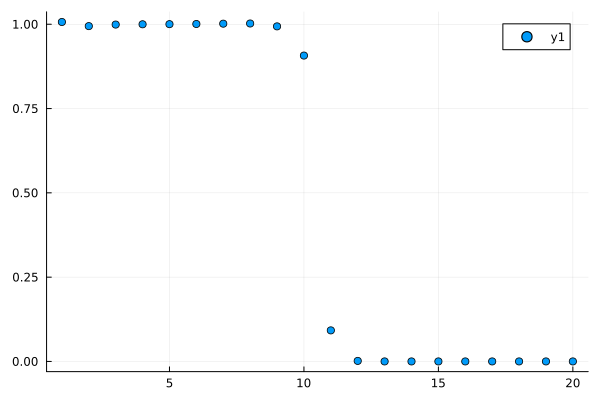

In [32]:
scatter(expect(gs1.ψ,"n"))

In [33]:
probs(gs1.ψ)

20×3 Matrix{Float64}:
 0.0157636  0.96173     0.0225063
 0.0386431  0.92822     0.0331365
 0.0368218  0.927259    0.0359188
 0.0364754  0.927101    0.0364237
 0.0363136  0.927062    0.036624
 0.0361007  0.926974    0.0369251
 0.0358     0.926656    0.0375441
 0.0361282  0.925454    0.0384176
 0.0429154  0.920415    0.0366697
 0.107245   0.878351    0.014404
 0.907981   0.091956    6.25844e-5
 0.998454   0.00154602  0.0
 0.99999    1.00489e-5  0.0
 1.0        0.0         0.0
 1.0        0.0         0.0
 1.0        0.0         0.0
 1.0        0.0         0.0
 1.0        0.0         0.0
 1.0        0.0         0.0
 1.0        0.0         0.0

In [34]:
gs1.observer.energylist

3-element Vector{Float64}:
 -0.9134949823046199
 -0.9135754788895412
 -0.9135754788307171

## Expansion

In [35]:
function expand(ψ₀;g,dg=0,η,dη=0,ω=0,time_step,T,
    tdvpopts=(;updater=krylov_updater,
            updater_kwargs=(;tol=1e-8,eager=true),
            cutoff=1e-6,maxdim=200,
            nsite=2,outputlevel=1
            ))
    Lx=length(ψ₀)
    sites=siteinds(ψ₀)
    K=MPO(Hopping(Lx),sites)
    U=MPO(Interactions(Lx),sites)
    H=TimeDependentSum([t->-im*(g+dg*sin(ω*t)),t->-im*(η+dη*sin(ω*t))],[K,U])
    obs=p_observer()
    println("calling tdvp")
    ψ = tdvp(H,T,ψ₀;tdvpopts...,time_step,(step_observer!)=obs)
    return (;ψ,obs)
end     

expand (generic function with 1 method)

In [36]:
@time ex1=expand(gs1.ψ;g=1,η=10,T=2,time_step=0.01,
    tdvpopts=(;updater=krylov_updater,
            updater_kwargs=(;tol=1e-8,eager=true),
            cutoff=1e-6,maxdim=200,
            nsite=2,outputlevel=1
            ))

calling tdvp
After sweep 1: maxlinkdim=8 maxerr=1.53E-08 current_time=0.01 time=21.888
After sweep 2: maxlinkdim=8 maxerr=1.53E-08 current_time=0.02 time=0.343
After sweep 3: maxlinkdim=8 maxerr=1.53E-08 current_time=0.03 time=0.18
After sweep 4: maxlinkdim=8 maxerr=1.53E-08 current_time=0.04 time=0.166
After sweep 5: maxlinkdim=8 maxerr=1.53E-08 current_time=0.05 time=0.16
After sweep 6: maxlinkdim=8 maxerr=1.53E-08 current_time=0.06 time=0.166
After sweep 7: maxlinkdim=8 maxerr=1.53E-08 current_time=0.07 time=0.163
After sweep 8: maxlinkdim=8 maxerr=1.53E-08 current_time=0.08 time=0.169
After sweep 9: maxlinkdim=8 maxerr=1.53E-08 current_time=0.09 time=0.156
After sweep 10: maxlinkdim=8 maxerr=1.53E-08 current_time=0.1 time=0.163
After sweep 11: maxlinkdim=8 maxerr=1.52E-08 current_time=0.11 time=0.162
After sweep 12: maxlinkdim=8 maxerr=1.52E-08 current_time=0.12 time=0.155
After sweep 13: maxlinkdim=8 maxerr=1.52E-08 current_time=0.13 time=0.161
After sweep 14: maxlinkdim=8 maxerr=

(ψ = MPS(20), obs = 200×3 DataFrame
 Row │ steps  times    probs                             
     │ Int64  Float64  Array…                            
─────┼───────────────────────────────────────────────────
   1 │     1     0.01  [0.0157632 0.961731 0.0225059; 0…
   2 │     2     0.02  [0.0157631 0.961731 0.0225058; 0…
   3 │     3     0.03  [0.0157631 0.961731 0.0225058; 0…
   4 │     4     0.04  [0.0157631 0.961731 0.0225056; 0…
   5 │     5     0.05  [0.0157631 0.961731 0.0225055; 0…
   6 │     6     0.06  [0.0157631 0.961732 0.0225054; 0…
   7 │     7     0.07  [0.0157631 0.961732 0.0225052; 0…
   8 │     8     0.08  [0.0157631 0.961732 0.022505; 0.…
   9 │     9     0.09  [0.0157631 0.961732 0.0225047; 0…
  10 │    10     0.1   [0.0157631 0.961732 0.0225045; 0…
  11 │    11     0.11  [0.0157631 0.961733 0.0225042; 0…
  ⋮  │   ⋮       ⋮                     ⋮
 191 │   191     1.91  [0.0157608 0.961688 0.0225514; 0…
 192 │   192     1.92  [0.0157624 0.961685 0.0225526; 0…
 193 │  

In [57]:
density(probs)=[sum((j-1)*p for (j,p) in enumerate(row)) for row in eachrow(probs)]

density (generic function with 1 method)

In [38]:
density(ex1.obs[1,"probs"])

20-element Vector{Float64}:
 1.0067427145195145
 0.9944933412300822
 0.9990966123567021
 0.9999492061997771
 1.000310698439282
 1.0008214087673806
 1.0017380140202388
 1.0022754126855777
 0.9937223181401291
 0.9071276765423717
 0.09216102309713911
 0.001551468052048028
 1.0105949740288058e-5
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0

In [39]:
size(ex1.obs[1,"probs"],1)

20

In [40]:
odensities(wrapper)=odensities(wrapper.obs)
odensities(obs::DataFrame)=stack([density(p) for p in obs[:,"probs"]])

odensities (generic function with 2 methods)

In [41]:
otimes(wrapper)=otimes(wrapper.obs)
otimes(obs::DataFrame)=obs.times

osites(wrapper)=osites(wrapper.obs)
osites(obs::DataFrame)=1:size(obs[1,"probs"],1)

osites (generic function with 2 methods)

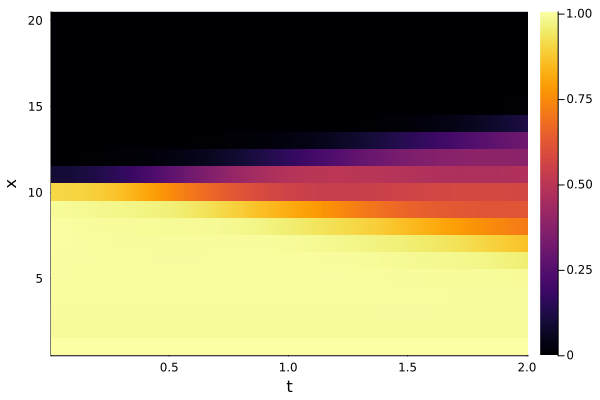

In [42]:
heatmap(otimes(ex1),osites(ex1),odensities(ex1),
xlabel="t",ylabel="x")

In [382]:
saveocs(ex1,"ex1.hdf5")

"ex1.hdf5"

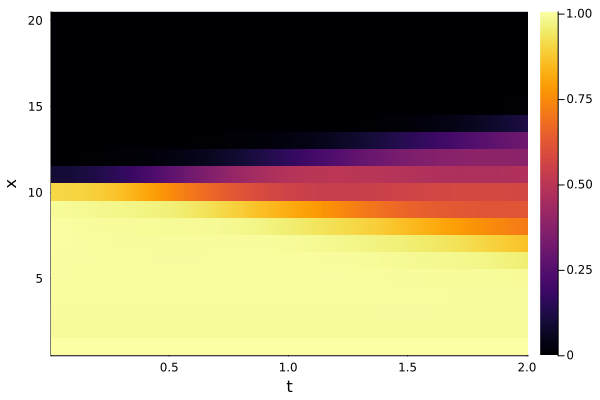

In [386]:
ex1times=h5read("ex1.hdf5","times")
ex1sites=h5read("ex1.hdf5","sites")
ex1densities=h5read("ex1.hdf5","densities")
ex1probs=h5read("ex1.hdf5","probs")
heatmap(ex1times,ex1sites,ex1densities, xlabel="t",ylabel="x")

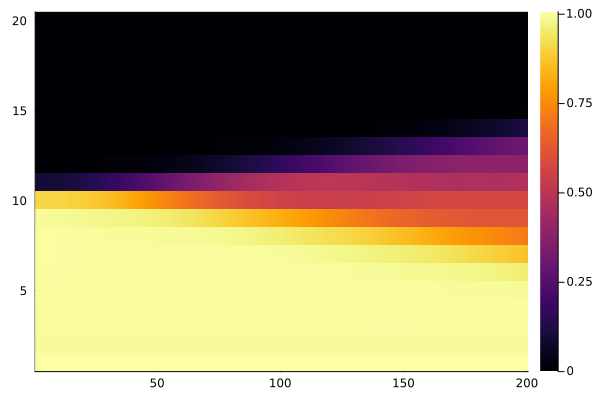

In [74]:
heatmap(stack([density(p) for p in ex1.obs[:,"probs"]]))

In [94]:
# larger time step
@time ex1b=expand(gs1.ψ;g=1,η=10,T=2,time_step=0.1,
    tdvpopts=(;updater=krylov_updater,
            updater_kwargs=(;tol=1e-8,eager=true),
            cutoff=1e-6,maxdim=200,
            nsite=2,outputlevel=1
            ));

After sweep 1: maxlinkdim=8 maxerr=8.56E-07 current_time=0.1 time=0.267
After sweep 2: maxlinkdim=8 maxerr=8.80E-07 current_time=0.2 time=0.265
After sweep 3: maxlinkdim=8 maxerr=9.63E-07 current_time=0.3 time=0.264
After sweep 4: maxlinkdim=8 maxerr=8.77E-07 current_time=0.4 time=0.276
After sweep 5: maxlinkdim=8 maxerr=9.73E-07 current_time=0.5 time=0.277
After sweep 6: maxlinkdim=8 maxerr=9.64E-07 current_time=0.6 time=0.265
After sweep 7: maxlinkdim=9 maxerr=8.96E-07 current_time=0.7 time=0.267
After sweep 8: maxlinkdim=9 maxerr=8.91E-07 current_time=0.8 time=0.299
After sweep 9: maxlinkdim=9 maxerr=8.85E-07 current_time=0.9 time=0.308
After sweep 10: maxlinkdim=9 maxerr=8.80E-07 current_time=1.0 time=0.311
After sweep 11: maxlinkdim=9 maxerr=8.77E-07 current_time=1.1 time=0.333
After sweep 12: maxlinkdim=9 maxerr=8.77E-07 current_time=1.2 time=0.315
After sweep 13: maxlinkdim=9 maxerr=8.84E-07 current_time=1.3 time=0.329
After sweep 14: maxlinkdim=9 maxerr=9.42E-07 current_time=1.

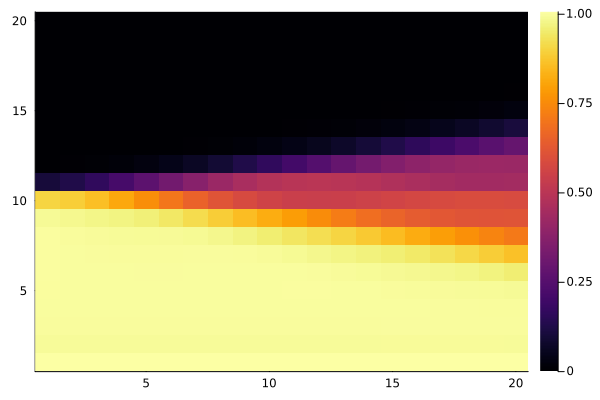

In [95]:
heatmap(stack([density(p) for p in ex1b.obs[:,"probs"]]))

Looks like the larger step is good enough.  Lets extend the time

In [96]:
@time ex1c=expand(gs1.ψ;g=1,η=10,T=4,time_step=0.1,
    tdvpopts=(;updater=krylov_updater,
            updater_kwargs=(;tol=1e-8,eager=true),
            cutoff=1e-6,maxdim=200,
            nsite=2,outputlevel=1
            ));

After sweep 1: maxlinkdim=8 maxerr=8.56E-07 current_time=0.1 time=0.273
After sweep 2: maxlinkdim=8 maxerr=8.80E-07 current_time=0.2 time=0.27
After sweep 3: maxlinkdim=8 maxerr=9.63E-07 current_time=0.3 time=0.27
After sweep 4: maxlinkdim=8 maxerr=8.77E-07 current_time=0.4 time=0.277
After sweep 5: maxlinkdim=8 maxerr=9.73E-07 current_time=0.5 time=0.278
After sweep 6: maxlinkdim=8 maxerr=9.64E-07 current_time=0.6 time=0.272
After sweep 7: maxlinkdim=9 maxerr=8.96E-07 current_time=0.7 time=0.285
After sweep 8: maxlinkdim=9 maxerr=8.91E-07 current_time=0.8 time=0.3
After sweep 9: maxlinkdim=9 maxerr=8.85E-07 current_time=0.9 time=0.297
After sweep 10: maxlinkdim=9 maxerr=8.80E-07 current_time=1.0 time=0.384
After sweep 11: maxlinkdim=9 maxerr=8.77E-07 current_time=1.1 time=0.317
After sweep 12: maxlinkdim=9 maxerr=8.77E-07 current_time=1.2 time=0.33
After sweep 13: maxlinkdim=9 maxerr=8.84E-07 current_time=1.3 time=0.335
After sweep 14: maxlinkdim=9 maxerr=9.42E-07 current_time=1.4 tim

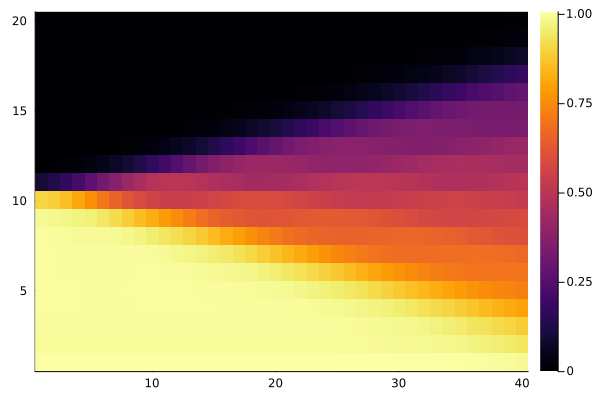

In [97]:
heatmap(stack([density(p) for p in ex1c.obs[:,"probs"]]))

In [98]:
ρslices=[density(p) for p in ex1c.obs[:,"probs"]]

40-element Vector{Vector{Float64}}:
 [1.0067420644509593, 0.9944914757091894, 0.9990870484718051, 0.9999219198702127, 1.0002400072077773, 1.0006348336872322, 1.0012389237502377, 1.000986745319606, 0.9907857510097307, 0.9036920988987808, 0.10005330019441308, 0.002109020846797044, 1.6810583257331423e-5, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
 [1.0067389761914136, 0.9944844659972019, 0.99906326956659, 0.9998595195742173, 1.0000720584321516, 1.0001822414745425, 1.0000367154562506, 0.9979427881141777, 0.9841141556987696, 0.8897688702173363, 0.12367102551629384, 0.004014931596307369, 5.098216474254456e-5, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
 [1.0067352420523443, 0.9944760224933191, 0.9990385747050713, 0.9997926303632119, 0.9998938968798571, 0.999703296437828, 0.9987864282195241, 0.9949497346027061, 0.9775805744246179, 0.8595094409099767, 0.1614774953999524, 0.0078958507643862, 0.00016081274720651333, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
 [1.0067309576257528, 0.9944681225459556, 0.9990219972996647, 

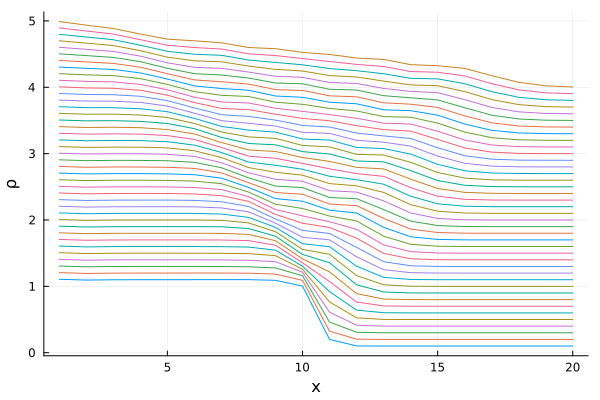

In [99]:
p=plot(xlabel="x",ylabel="ρ")
for (j,rho) in enumerate(ρslices)
    plot!(rho .+0.1*j,label="")
end
p

In [100]:
"""
    width(probs)

Given a Lxn matrix probs, calculates the first spatial moment
"""
width(probs)=sum((j[2]-1)*(j[1]-1)*p for (j,p) in pairs(probs))/
    sum((j[2]-1)*p for (j,p) in pairs(probs))

width

In [155]:
function linextrap(values,target)
    j=findfirst(x->x<target,values)
    vj=values[j]
    i=j-1
    vi=values[i]
    return (target*(j-i)+i*vj-j*vi)/(vj-vi)
end

linextrap (generic function with 1 method)

In [158]:
linextrap([1,0.5,0.2,0],0.1)

3.5

In [159]:
"""
    fw(probs)

gives the width of the density to go from 1/4 to 3/4 of its maximum value
"""
function fw(probs)
    d=density(probs)
    m=maximum(d)
    a=linextrap(d,3*m/4)
    b=linextrap(d,m/4)
    return b-a
end    

fw

In [145]:
"""
    hwhm(probs)

Gives the half-width-half max width of the cloud"""
function hwhm(probs)
    d=density(probs)
    m=maximum(d)
    j=findfirst(x->x<m/2,d)
    dj=d[j]
    i=j-1
    di=d[i]
    return ((m/2)*(j-i)+i*dj-j*di)/(dj-di)
end

hwhm

In [101]:
width(ex1c.obs[1,"probs"])

4.509435514569423

In [146]:
hwhm(ex1c.obs[1,"probs"])

10.498135564533097

In [160]:
fw(ex1c.obs[1,"probs"])

0.6263647711347655

In [149]:
hwhm(ex1c.obs[end,"probs"])

10.980502994791047

In [161]:
(ex1c.obs[end,"probs"])

20×3 Matrix{Float64}:
 0.0295223  0.950303    0.0201746
 0.0914676  0.880702    0.0278305
 0.137606   0.839169    0.0232255
 0.214158   0.769743    0.016099
 0.285855   0.703019    0.0111256
 0.308981   0.681256    0.00976342
 0.337595   0.654552    0.00785295
 0.405414   0.589676    0.00491063
 0.422484   0.573488    0.00402882
 0.476677   0.520819    0.00250373
 0.507085   0.491111    0.00180416
 0.559977   0.438989    0.00103468
 0.581011   0.418228    0.000761472
 0.659213   0.340441    0.000346114
 0.675073   0.324771    0.000156095
 0.71554    0.284389    7.17036e-5
 0.825171   0.17481     1.88417e-5
 0.925477   0.0745221   1.00787e-6
 0.978106   0.0218939   0.0
 0.995298   0.00470175  0.0

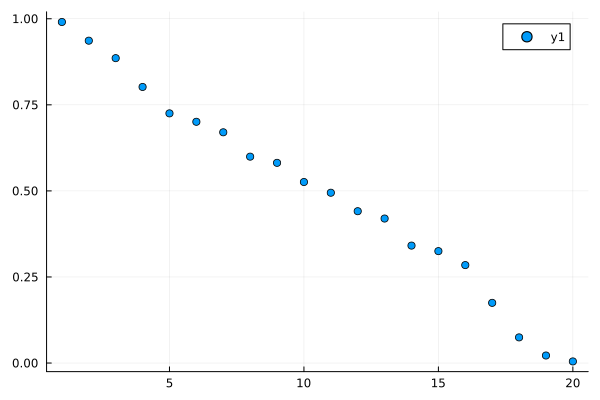

In [150]:
scatter(density(ex1c.obs[end,"probs"]))

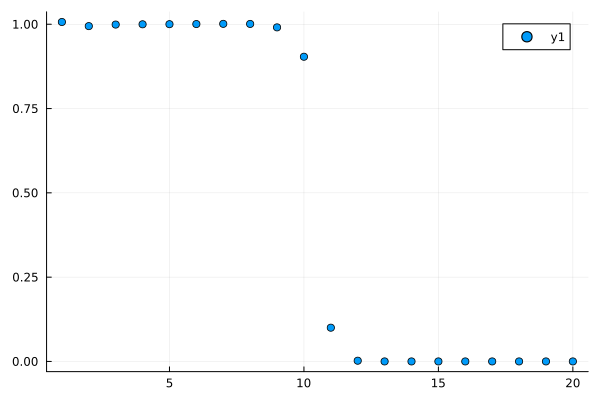

In [147]:
scatter(density(ex1c.obs[1,"probs"]))

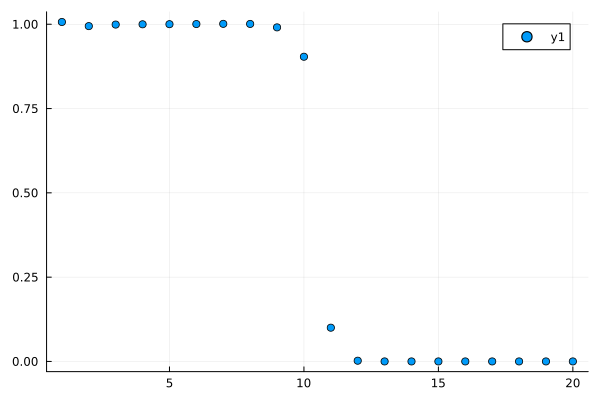

In [102]:
scatter(density(ex1c.obs[1,"probs"]))

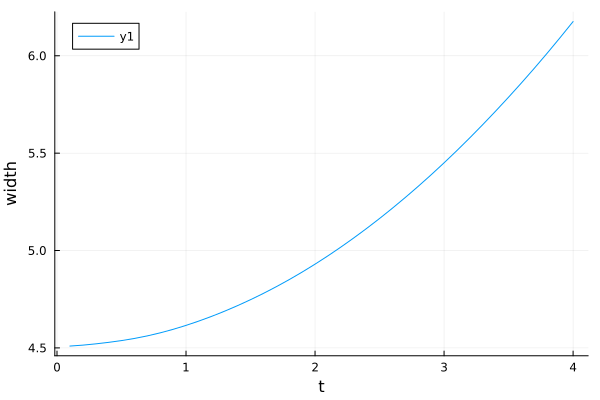

In [105]:
w1c=[width(p) for p in ex1c.obs[:,"probs"]]
plot(ex1c.obs[:,"times"],w1c;xlabel="t",ylabel="width")

After sweep 1 energy=-17.89637458541769  maxlinkdim=17 maxerr=9.04E-07 time=0.091
After sweep 2 energy=-18.948581500370587  maxlinkdim=43 maxerr=9.74E-07 time=0.322
After sweep 3 energy=-19.363449419430722  maxlinkdim=40 maxerr=9.64E-07 time=0.387
After sweep 4 energy=-19.510357476329105  maxlinkdim=33 maxerr=9.89E-07 time=0.374
After sweep 5 energy=-19.55095552647953  maxlinkdim=24 maxerr=9.99E-07 time=0.697
After sweep 6 energy=-19.560926290017225  maxlinkdim=16 maxerr=9.98E-07 time=0.293
After sweep 7 energy=-19.56296932316586  maxlinkdim=14 maxerr=9.33E-07 time=0.233
After sweep 8 energy=-19.56312106648033  maxlinkdim=11 maxerr=9.84E-07 time=0.193
After sweep 9 energy=-19.563142108698386  maxlinkdim=11 maxerr=8.19E-07 time=0.177
After sweep 10 energy=-19.56314523578873  maxlinkdim=11 maxerr=6.92E-07 time=0.177
After sweep 11 energy=-19.563145789696037  maxlinkdim=11 maxerr=7.38E-07 time=0.178
After sweep 12 energy=-19.563145889419907  maxlinkdim=11 maxerr=7.47E-07 time=0.178
Stoppi

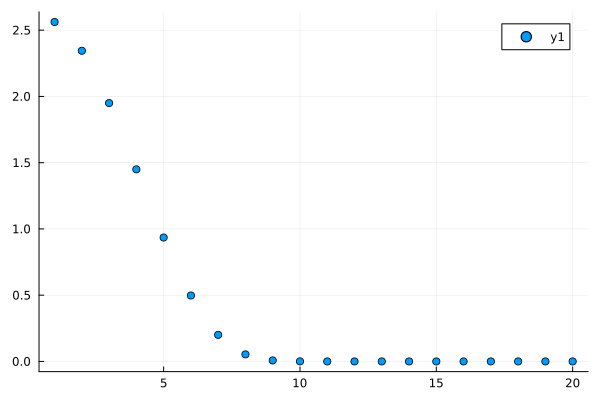

In [93]:
@time gs2=findgs(10,well(20;V=20,L=12,s=2);t=1,U=0,maxn=10,
    dmrgopts=(nsweeps=50,maxdim=100,cutoff=1E-6,outputlevel=1))
scatter(expect(gs2.ψ,"n"))

Even though this is non-interacting, it is still somewhat slow because of the large local Hilbert space.  The cloud is much smaller, so I can expand for longer with this system size -- or I could use a smaller system size.  

In [110]:
@time ex2=expand(gs2.ψ;g=1,η=0,T=12,time_step=0.1,
    tdvpopts=(;updater=krylov_updater,
            updater_kwargs=(;tol=1e-8,eager=true),
            cutoff=1e-6,maxdim=200,
            nsite=2,outputlevel=1
            ));

After sweep 1: maxlinkdim=11 maxerr=6.97E-08 current_time=0.1 time=0.602
After sweep 2: maxlinkdim=11 maxerr=6.89E-08 current_time=0.2 time=0.587
After sweep 3: maxlinkdim=11 maxerr=6.89E-08 current_time=0.3 time=0.586
After sweep 4: maxlinkdim=11 maxerr=9.40E-08 current_time=0.4 time=0.58
After sweep 5: maxlinkdim=11 maxerr=1.52E-07 current_time=0.5 time=0.59
After sweep 6: maxlinkdim=11 maxerr=2.37E-07 current_time=0.6 time=0.613
After sweep 7: maxlinkdim=11 maxerr=3.57E-07 current_time=0.7 time=0.587
After sweep 8: maxlinkdim=11 maxerr=5.19E-07 current_time=0.8 time=0.587
After sweep 9: maxlinkdim=11 maxerr=7.32E-07 current_time=0.9 time=0.592
After sweep 10: maxlinkdim=11 maxerr=1.89E-07 current_time=1.0 time=0.602
After sweep 11: maxlinkdim=11 maxerr=2.48E-07 current_time=1.1 time=0.554
After sweep 12: maxlinkdim=11 maxerr=3.20E-07 current_time=1.2 time=0.56
After sweep 13: maxlinkdim=11 maxerr=4.07E-07 current_time=1.3 time=0.962
After sweep 14: maxlinkdim=11 maxerr=5.11E-07 curr

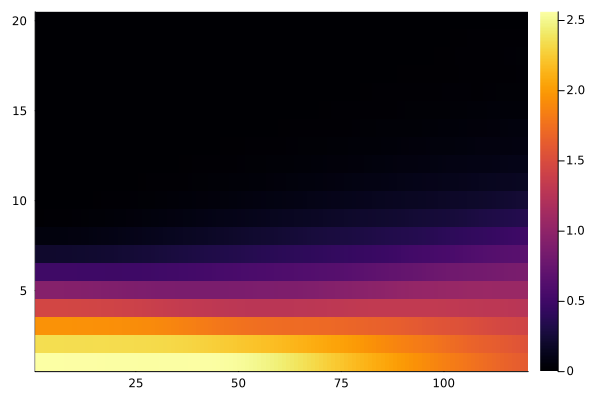

In [111]:
heatmap(stack([density(p) for p in ex2.obs[:,"probs"]]))

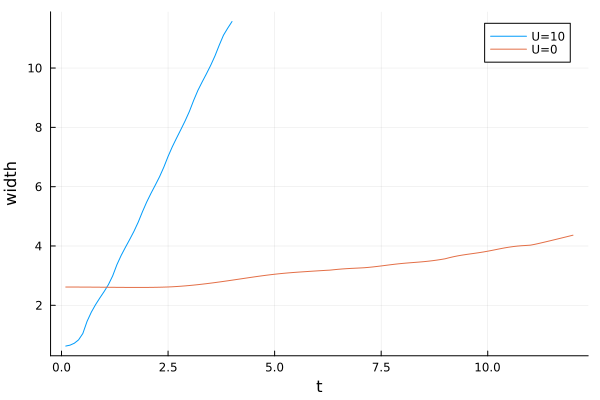

In [162]:
w1c=[fw(p) for p in ex1c.obs[:,"probs"]]
w2=[fw(p) for p in ex2.obs[:,"probs"]]
plot(ex1c.obs[:,"times"],w1c;xlabel="t",ylabel="width",label="U=10")
plot!(ex2.obs[:,"times"],w2;xlabel="t",ylabel="width",label="U=0")

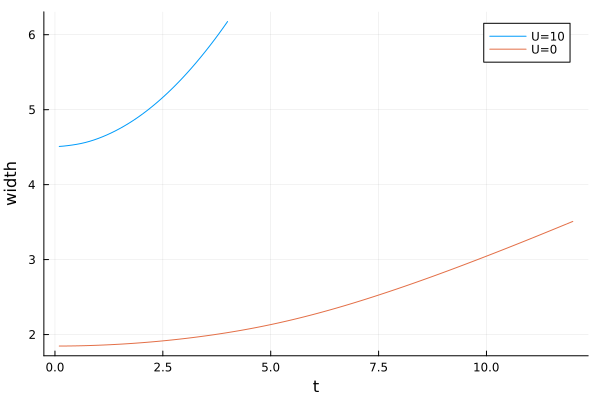

In [112]:
w1c=[width(p) for p in ex1c.obs[:,"probs"]]
w2=[width(p) for p in ex2.obs[:,"probs"]]
plot(ex1c.obs[:,"times"],w1c;xlabel="t",ylabel="width",label="U=10")
plot!(ex2.obs[:,"times"],w2;xlabel="t",ylabel="width",label="U=0")

After sweep 1 energy=-15.584806446151802  maxlinkdim=16 maxerr=9.18E-07 time=0.085
After sweep 2 energy=-15.648094752161168  maxlinkdim=23 maxerr=9.89E-07 time=0.154
After sweep 3 energy=-15.649647754299579  maxlinkdim=22 maxerr=9.63E-07 time=0.175
After sweep 4 energy=-15.649642824616182  maxlinkdim=22 maxerr=9.90E-07 time=0.169
After sweep 5 energy=-15.649643054781006  maxlinkdim=22 maxerr=9.60E-07 time=0.159
After sweep 6 energy=-15.649643059611513  maxlinkdim=22 maxerr=9.60E-07 time=0.168
Stopping DMRG after sweep 6
  0.923562 seconds (11.72 M allocations: 1.533 GiB, 12.17% gc time, 0.02% compilation time)


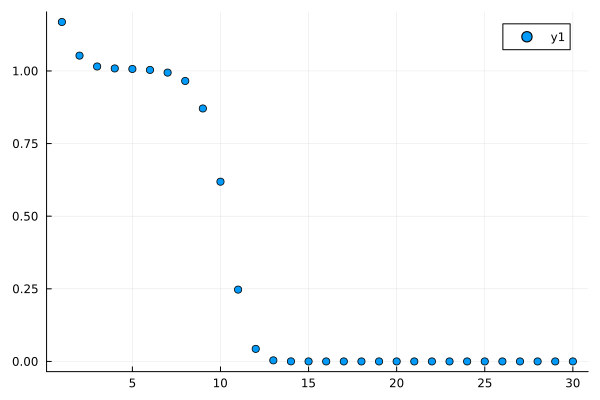

In [130]:
@time gs3=findgs(10,well(30;V=4,L=12.5,s=2);t=1,U=1,maxn=3,
    dmrgopts=(nsweeps=50,maxdim=100,cutoff=1E-6,outputlevel=1))
scatter(expect(gs3.ψ,"n"))

In [131]:
@time ex3=expand(gs3.ψ;g=1,η=1,T=8,time_step=0.1,
    tdvpopts=(;updater=krylov_updater,
            updater_kwargs=(;tol=1e-8,eager=true),
            cutoff=1e-6,maxdim=200,
            nsite=2,outputlevel=1
            ));

After sweep 1: maxlinkdim=19 maxerr=9.61E-07 current_time=0.1 time=0.635
After sweep 2: maxlinkdim=19 maxerr=4.66E-07 current_time=0.2 time=0.612
After sweep 3: maxlinkdim=19 maxerr=9.72E-07 current_time=0.3 time=0.619
After sweep 4: maxlinkdim=19 maxerr=4.20E-07 current_time=0.4 time=0.612
After sweep 5: maxlinkdim=19 maxerr=5.43E-07 current_time=0.5 time=0.607
After sweep 6: maxlinkdim=19 maxerr=9.79E-07 current_time=0.6 time=0.612
After sweep 7: maxlinkdim=19 maxerr=5.12E-07 current_time=0.7 time=0.612
After sweep 8: maxlinkdim=19 maxerr=5.07E-07 current_time=0.8 time=0.613
After sweep 9: maxlinkdim=19 maxerr=5.77E-07 current_time=0.9 time=0.61
After sweep 10: maxlinkdim=18 maxerr=7.88E-07 current_time=1.0 time=0.612
After sweep 11: maxlinkdim=18 maxerr=6.84E-07 current_time=1.1 time=0.617
After sweep 12: maxlinkdim=18 maxerr=5.18E-07 current_time=1.2 time=0.621
After sweep 13: maxlinkdim=18 maxerr=5.18E-07 current_time=1.3 time=0.621
After sweep 14: maxlinkdim=18 maxerr=6.47E-07 cu

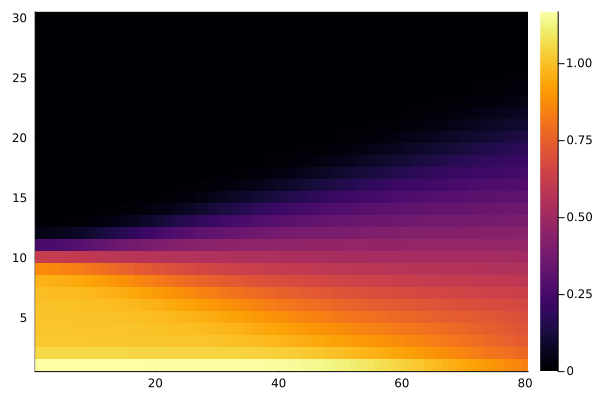

In [132]:
heatmap(stack([density(p) for p in ex3.obs[:,"probs"]]))

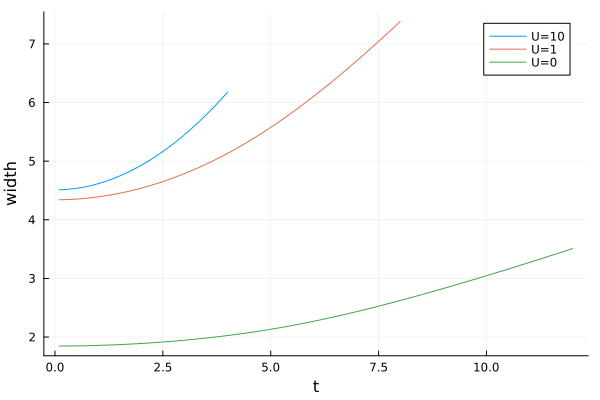

In [133]:
w1c=[width(p) for p in ex1c.obs[:,"probs"]]
w2=[width(p) for p in ex2.obs[:,"probs"]]
w3=[width(p) for p in ex3.obs[:,"probs"]]
plot(ex1c.obs[:,"times"],w1c;xlabel="t",ylabel="width",label="U=10")
plot!(ex3.obs[:,"times"],w3;xlabel="t",ylabel="width",label="U=1")
plot!(ex2.obs[:,"times"],w2;xlabel="t",ylabel="width",label="U=0")

After sweep 1 energy=-17.21882457145941  maxlinkdim=15 maxerr=6.22E-07 time=0.086
After sweep 2 energy=-17.37988946599589  maxlinkdim=28 maxerr=1.00E-06 time=0.221
After sweep 3 energy=-17.40302999523364  maxlinkdim=24 maxerr=9.58E-07 time=0.242
After sweep 4 energy=-17.40460172889667  maxlinkdim=21 maxerr=9.98E-07 time=0.245
After sweep 5 energy=-17.404612905471964  maxlinkdim=21 maxerr=9.36E-07 time=0.243
After sweep 6 energy=-17.40461096687838  maxlinkdim=20 maxerr=9.93E-07 time=0.242
After sweep 7 energy=-17.404611075562983  maxlinkdim=20 maxerr=9.55E-07 time=0.242
Stopping DMRG after sweep 7
  1.580199 seconds (19.61 M allocations: 2.541 GiB, 12.81% gc time)


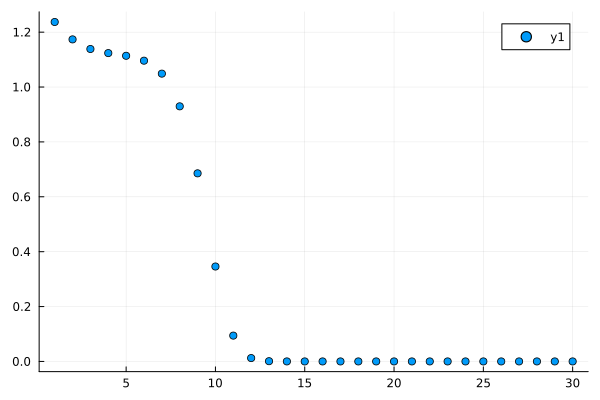

In [164]:
@time gs4=findgs(10,well(30;V=4,L=12.5,s=2);t=1,U=0.5,maxn=4,
    dmrgopts=(nsweeps=50,maxdim=100,cutoff=1E-6,outputlevel=1))
scatter(expect(gs4.ψ,"n"))

In [136]:
@time ex4=expand(gs4.ψ;g=1,η=0.5,T=8,time_step=0.1,
    tdvpopts=(;updater=krylov_updater,
            updater_kwargs=(;tol=1e-8,eager=true),
            cutoff=1e-6,maxdim=200,
            nsite=2,outputlevel=1
            ));

After sweep 1: maxlinkdim=19 maxerr=9.58E-07 current_time=0.1 time=1.313
After sweep 2: maxlinkdim=19 maxerr=5.23E-07 current_time=0.2 time=0.908
After sweep 3: maxlinkdim=19 maxerr=5.10E-07 current_time=0.3 time=0.872
After sweep 4: maxlinkdim=19 maxerr=4.99E-07 current_time=0.4 time=0.893
After sweep 5: maxlinkdim=19 maxerr=4.91E-07 current_time=0.5 time=0.904
After sweep 6: maxlinkdim=18 maxerr=5.60E-07 current_time=0.6 time=0.899
After sweep 7: maxlinkdim=18 maxerr=5.48E-07 current_time=0.7 time=0.865
After sweep 8: maxlinkdim=18 maxerr=5.42E-07 current_time=0.8 time=0.89
After sweep 9: maxlinkdim=18 maxerr=5.39E-07 current_time=0.9 time=0.889
After sweep 10: maxlinkdim=18 maxerr=5.38E-07 current_time=1.0 time=0.931
After sweep 11: maxlinkdim=18 maxerr=6.26E-07 current_time=1.1 time=0.902
After sweep 12: maxlinkdim=18 maxerr=8.84E-07 current_time=1.2 time=0.887
After sweep 13: maxlinkdim=18 maxerr=5.41E-07 current_time=1.3 time=0.915
After sweep 14: maxlinkdim=18 maxerr=6.07E-07 cu

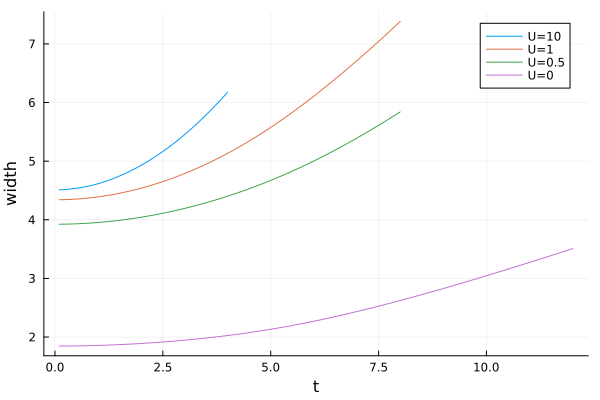

In [137]:
w1c=[width(p) for p in ex1c.obs[:,"probs"]]
w2=[width(p) for p in ex2.obs[:,"probs"]]
w3=[width(p) for p in ex3.obs[:,"probs"]]
w4=[width(p) for p in ex4.obs[:,"probs"]]
plot(ex1c.obs[:,"times"],w1c;xlabel="t",ylabel="width",label="U=10")
plot!(ex3.obs[:,"times"],w3;xlabel="t",ylabel="width",label="U=1")
plot!(ex4.obs[:,"times"],w4;xlabel="t",ylabel="width",label="U=0.5")
plot!(ex2.obs[:,"times"],w2;xlabel="t",ylabel="width",label="U=0")

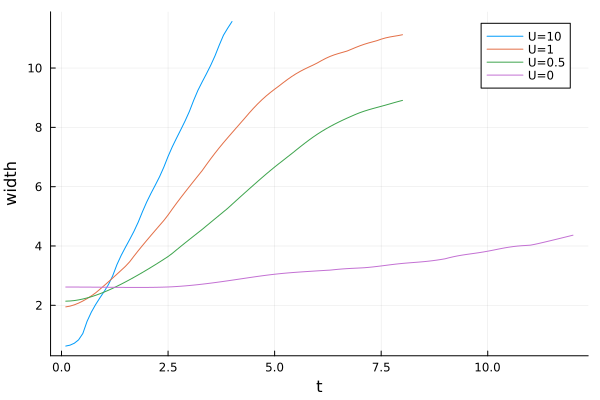

In [163]:
w1c=[fw(p) for p in ex1c.obs[:,"probs"]]
w2=[fw(p) for p in ex2.obs[:,"probs"]]
w3=[fw(p) for p in ex3.obs[:,"probs"]]
w4=[fw(p) for p in ex4.obs[:,"probs"]]
plot(ex1c.obs[:,"times"],w1c;xlabel="t",ylabel="width",label="U=10")
plot!(ex3.obs[:,"times"],w3;xlabel="t",ylabel="width",label="U=1")
plot!(ex4.obs[:,"times"],w4;xlabel="t",ylabel="width",label="U=0.5")
plot!(ex2.obs[:,"times"],w2;xlabel="t",ylabel="width",label="U=0")

# Single Particle

To make sure this is correct, lets quickly do the single particle problem

In [256]:
using LinearAlgebra

In [262]:
function spbhm(t, U, len;V=nothing)
    a=zeros(len)
    b=zeros(len-1)
    a[1]=-t
    if V!=nothing
        for j in 1:len
            a[j] += V[j]
        end
    end
    for j in 1:len-1
        b[j]=-t
    end
    return SymTridiagonal(a,b)
end

spbhm (generic function with 1 method)

In [273]:
h0=spbhm(1,0,30;V=well(30;V=20,L=10.5,s=0));

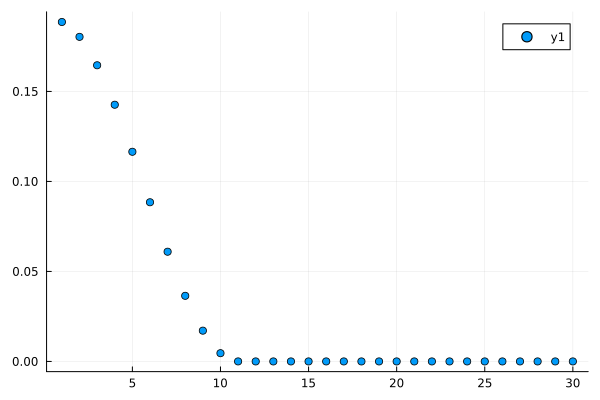

In [274]:
eg1=eigen(h0,1:1)
scatter(eg1.vectors[:,1].^2)

In [275]:
h1=spbhm(1,0,30);

In [260]:
using DifferentialEquations

In [290]:
f(u,p,t)=-im*h1*u
u1=eg1.vectors[:,1] .+(0.0*im)
prob=ODEProblem(f,u1,(0,50))
@time sol=solve(prob);

  1.595126 seconds (3.98 M allocations: 215.455 MiB, 1.71% gc time, 99.84% compilation time: 100% of which was recompilation)


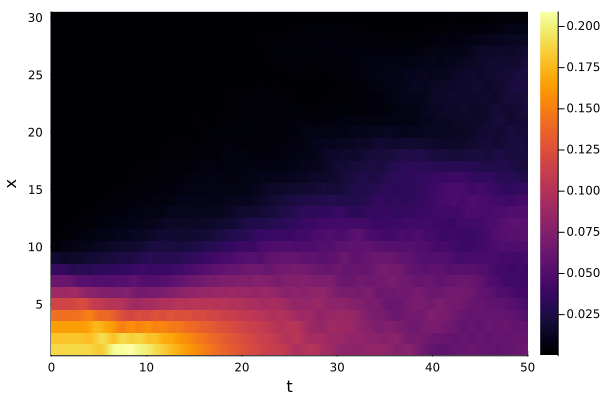

In [292]:
times=0:0.1:50
densities=stack([abs2.(sol(t)) for t in times])
heatmap(times,1:30,densities,xlabel="t",ylabel="x")

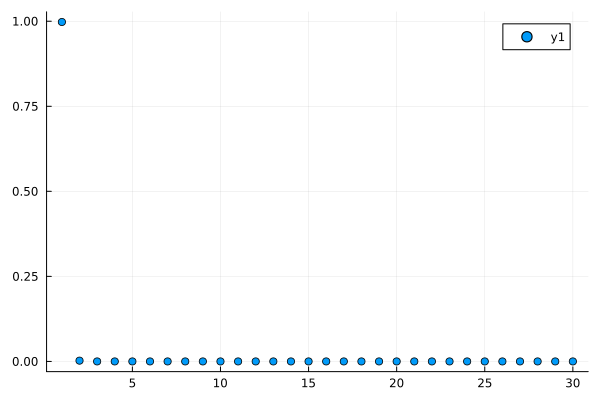

In [294]:
h0b=spbhm(1,0,30;V=well(30;V=20,L=1.5,s=0));
eg2=eigen(h0b,1:1)
scatter(eg2.vectors[:,1].^2)

In [295]:
u2=eg2.vectors[:,1] .+(0.0*im)
prob=ODEProblem(f,u2,(0,50))
@time sol2=solve(prob);

  0.001731 seconds (29.05 k allocations: 8.587 MiB)


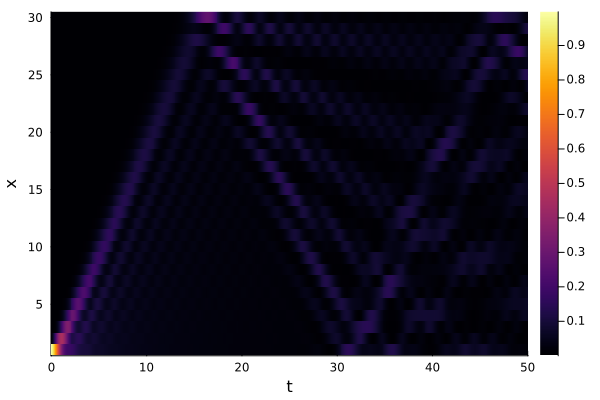

In [296]:
times2=0:0.1:50
densities2=stack([abs2.(sol2(t)) for t in times2])
heatmap(times2,1:30,densities2,xlabel="t",ylabel="x")

# Hard Wall box

To simplify things, lets just use a hard-wall box.

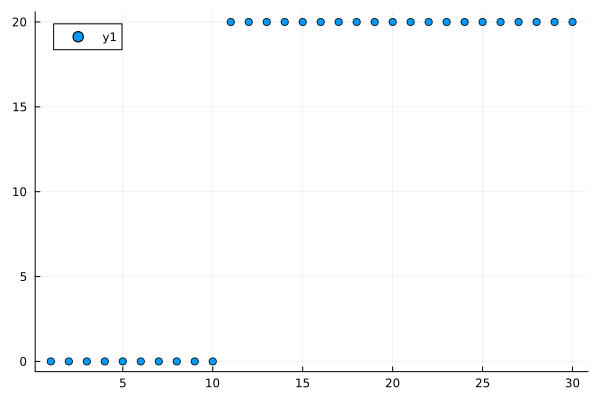

In [204]:
scatter(well(30;V=20,L=10.5,s=0))

After sweep 1 energy=-3.9102471557974106  maxlinkdim=4 maxerr=6.70E-07 time=0.030
After sweep 2 energy=-3.9540871677281673  maxlinkdim=5 maxerr=4.64E-07 time=0.185
After sweep 3 energy=-3.9557008647868974  maxlinkdim=3 maxerr=5.61E-07 time=0.025
After sweep 4 energy=-3.955723454150911  maxlinkdim=3 maxerr=3.91E-08 time=0.025
After sweep 5 energy=-3.9557237718334823  maxlinkdim=3 maxerr=3.94E-08 time=0.409
After sweep 6 energy=-3.9557237770533895  maxlinkdim=3 maxerr=3.94E-08 time=0.021
Stopping DMRG after sweep 6
  0.713537 seconds (1.67 M allocations: 271.205 MiB, 74.85% gc time)


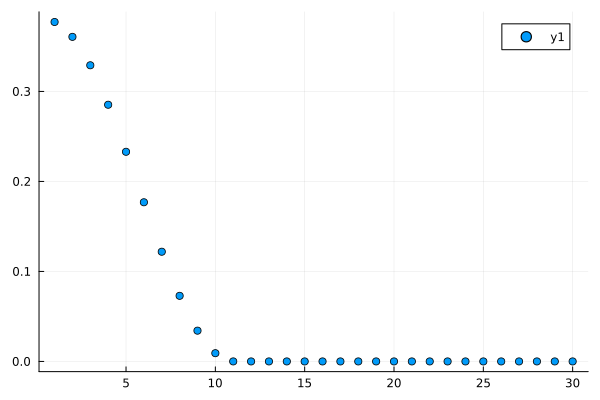

In [205]:
@time tst1=findgs(2,well(30;V=20,L=10.5,s=0);t=1,U=0.,maxn=2,
    dmrgopts=(nsweeps=50,maxdim=100,cutoff=1E-6,outputlevel=1))
scatter(expect(tst1.ψ,"n"))

In [300]:
sum(u1.^2)

0.9999999999999998 + 0.0im

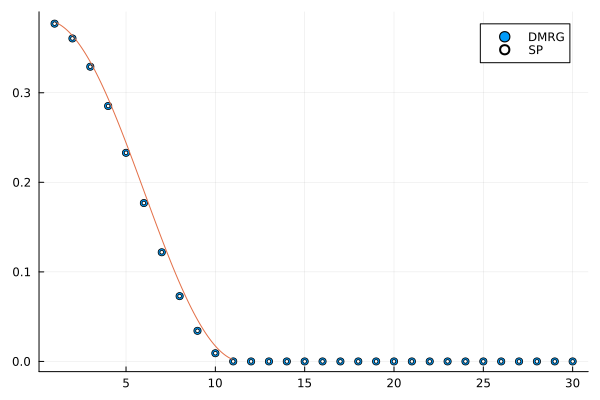

In [307]:
xv=1:0.1:11
yv=[(4/10.5)*cos((x-1/2)*pi/(2*11))^2 for x in xv]
scatter(expect(tst1.ψ,"n"),label="DMRG")
plot!(xv,yv,label="")
scatter!(1:30,2*abs2.(u1),c=:white,ms=2,label="SP")

After sweep 1 energy=-1.0476188038762841  maxlinkdim=2 maxerr=1.16E-08 time=0.006
After sweep 2 energy=-1.0476188038762841  maxlinkdim=2 maxerr=1.16E-08 time=0.004
Stopping DMRG after sweep 2
  0.014223 seconds (140.43 k allocations: 21.874 MiB)


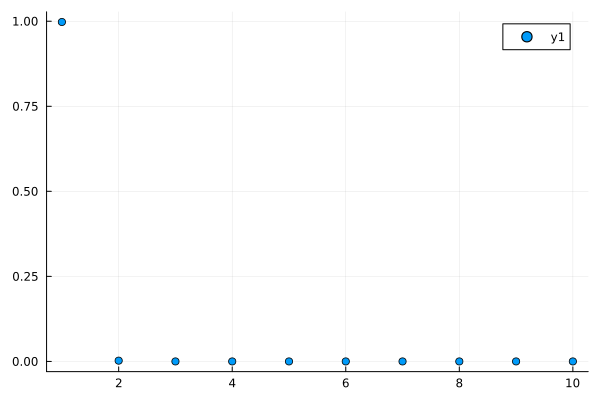

In [209]:
@time tst2=findgs(1,well(10;V=20,L=1.5,s=0);t=1,U=0.,maxn=2,
    dmrgopts=(nsweeps=50,maxdim=100,cutoff=1E-6,outputlevel=1))
scatter(expect(tst2.ψ,"n"))

calling tdvp
After sweep 1: maxlinkdim=2 maxerr=3.05E-08 current_time=0.1 time=0.015
After sweep 2: maxlinkdim=2 maxerr=5.35E-07 current_time=0.2 time=0.016
After sweep 3: maxlinkdim=2 maxerr=9.48E-09 current_time=0.3 time=0.021
After sweep 4: maxlinkdim=2 maxerr=1.19E-07 current_time=0.4 time=0.011
After sweep 5: maxlinkdim=2 maxerr=5.77E-07 current_time=0.5 time=0.01
After sweep 6: maxlinkdim=2 maxerr=6.73E-09 current_time=0.6 time=0.012
After sweep 7: maxlinkdim=2 maxerr=6.68E-08 current_time=0.7 time=0.017
After sweep 8: maxlinkdim=2 maxerr=2.79E-07 current_time=0.8 time=0.011
After sweep 9: maxlinkdim=2 maxerr=8.34E-07 current_time=0.9 time=0.011
After sweep 10: maxlinkdim=2 maxerr=8.12E-09 current_time=1.0 time=0.013
After sweep 11: maxlinkdim=2 maxerr=7.04E-08 current_time=1.1 time=0.013
After sweep 12: maxlinkdim=2 maxerr=2.65E-07 current_time=1.2 time=0.016
After sweep 13: maxlinkdim=2 maxerr=7.27E-07 current_time=1.3 time=0.012
After sweep 14: maxlinkdim=2 maxerr=6.79E-09 cur

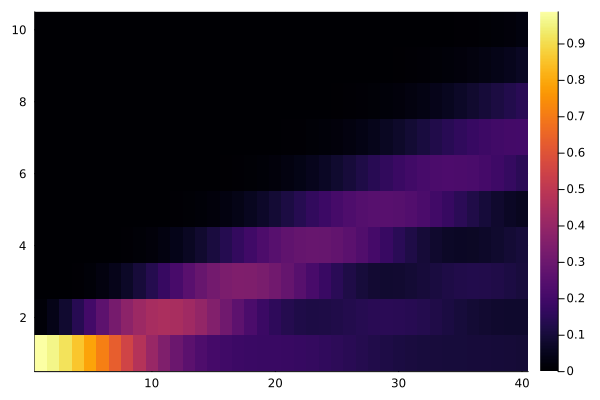

In [210]:
tstexp2=expand(tst2.ψ;g=1,η=0.,T=4,time_step=0.1,
    tdvpopts=(;updater=krylov_updater,
            updater_kwargs=(;tol=1e-8,eager=true),
            cutoff=1e-6,maxdim=200,
            nsite=2,outputlevel=1
            ));
heatmap(stack([density(p) for p in tstexp2.obs[:,"probs"]]))

calling tdvp
After sweep 1: maxlinkdim=3 maxerr=2.43E-08 current_time=1.0 time=0.074
After sweep 2: maxlinkdim=3 maxerr=6.97E-07 current_time=2.0 time=0.087
After sweep 3: maxlinkdim=3 maxerr=5.34E-07 current_time=3.0 time=0.107
After sweep 4: maxlinkdim=3 maxerr=4.83E-08 current_time=4.0 time=0.113
After sweep 5: maxlinkdim=3 maxerr=1.63E-08 current_time=5.0 time=0.108
After sweep 6: maxlinkdim=3 maxerr=7.41E-07 current_time=6.0 time=0.121
After sweep 7: maxlinkdim=3 maxerr=4.88E-08 current_time=7.0 time=0.124
After sweep 8: maxlinkdim=3 maxerr=3.17E-08 current_time=8.0 time=0.129
After sweep 9: maxlinkdim=3 maxerr=6.67E-07 current_time=9.0 time=0.135
After sweep 10: maxlinkdim=3 maxerr=4.46E-08 current_time=10.0 time=0.137
After sweep 11: maxlinkdim=3 maxerr=8.34E-07 current_time=11.0 time=0.142
After sweep 12: maxlinkdim=3 maxerr=5.46E-08 current_time=12.0 time=0.141
After sweep 13: maxlinkdim=3 maxerr=9.48E-07 current_time=13.0 time=0.152
After sweep 14: maxlinkdim=3 maxerr=5.65E-0

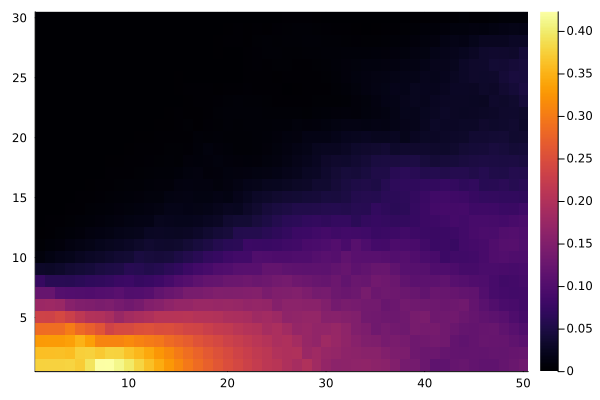

In [218]:
tstexp1=expand(tst1.ψ;g=1,η=0.,T=50,time_step=1.,
    tdvpopts=(;updater=krylov_updater,
            updater_kwargs=(;tol=1e-8,eager=true),
            cutoff=1e-6,maxdim=200,
            nsite=2,outputlevel=1
            ));
heatmap(stack([density(p) for p in tstexp1.obs[:,"probs"]]))

After sweep 1 energy=-19.262068358461455  maxlinkdim=15 maxerr=8.56E-07 time=0.082
After sweep 2 energy=-19.58970250776049  maxlinkdim=37 maxerr=9.67E-07 time=0.317
After sweep 3 energy=-19.704505582428276  maxlinkdim=31 maxerr=9.95E-07 time=0.413
After sweep 4 energy=-19.75216999976577  maxlinkdim=26 maxerr=9.99E-07 time=0.409
After sweep 5 energy=-19.77057648379127  maxlinkdim=22 maxerr=9.95E-07 time=0.391
After sweep 6 energy=-19.776782990711933  maxlinkdim=15 maxerr=9.92E-07 time=0.341
After sweep 7 energy=-19.778288824283774  maxlinkdim=14 maxerr=9.72E-07 time=0.271
After sweep 8 energy=-19.778544590807197  maxlinkdim=11 maxerr=8.61E-07 time=0.247
After sweep 9 energy=-19.778605484119897  maxlinkdim=11 maxerr=3.22E-07 time=0.246
After sweep 10 energy=-19.778609372832513  maxlinkdim=11 maxerr=9.95E-07 time=0.224
After sweep 11 energy=-19.778610999393695  maxlinkdim=11 maxerr=8.73E-07 time=0.238
After sweep 12 energy=-19.778611296607448  maxlinkdim=11 maxerr=8.63E-07 time=0.233
Afte

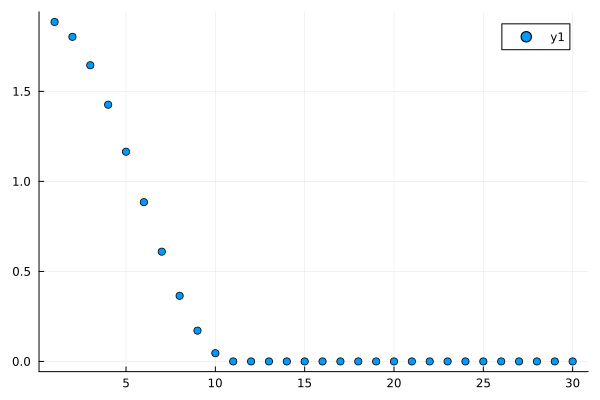

In [165]:
@time ghw0=findgs(10,well(30;V=20,L=10.5,s=0);t=1,U=0.,maxn=10,
    dmrgopts=(nsweeps=50,maxdim=100,cutoff=1E-6,outputlevel=1))
scatter(expect(ghw0.ψ,"n"))

After sweep 1: maxlinkdim=11 maxerr=8.17E-07 current_time=0.1 time=0.732
After sweep 2: maxlinkdim=11 maxerr=2.68E-07 current_time=0.2 time=0.779
After sweep 3: maxlinkdim=11 maxerr=6.00E-07 current_time=0.3 time=0.752
After sweep 4: maxlinkdim=11 maxerr=4.19E-07 current_time=0.4 time=0.707
After sweep 5: maxlinkdim=11 maxerr=6.31E-08 current_time=0.5 time=0.759
After sweep 6: maxlinkdim=11 maxerr=6.23E-08 current_time=0.6 time=0.758
After sweep 7: maxlinkdim=11 maxerr=1.03E-07 current_time=0.7 time=1.119
After sweep 8: maxlinkdim=11 maxerr=2.92E-07 current_time=0.8 time=0.742
After sweep 9: maxlinkdim=11 maxerr=6.54E-07 current_time=0.9 time=0.746
After sweep 10: maxlinkdim=11 maxerr=3.69E-07 current_time=1.0 time=0.761
After sweep 11: maxlinkdim=11 maxerr=5.46E-07 current_time=1.1 time=0.756
After sweep 12: maxlinkdim=11 maxerr=7.32E-07 current_time=1.2 time=0.756
After sweep 13: maxlinkdim=11 maxerr=9.05E-07 current_time=1.3 time=0.758
After sweep 14: maxlinkdim=11 maxerr=5.77E-07 c

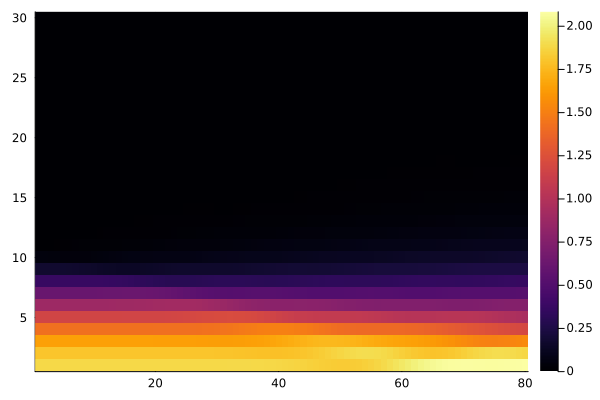

In [166]:
@time exhw0=expand(ghw0.ψ;g=1,η=0.,T=8,time_step=0.1,
    tdvpopts=(;updater=krylov_updater,
            updater_kwargs=(;tol=1e-8,eager=true),
            cutoff=1e-6,maxdim=200,
            nsite=2,outputlevel=1
            ));
heatmap(stack([density(p) for p in exhw0.obs[:,"probs"]]))

The non-interacting case has particles with very small momenta, so they don't expand much...  Our direct solution of the single particle problem gives the same result.

In [316]:
if 3!=nothing; 5; end

5

In [336]:
function tdvpexp(;num,trap,g=1,dg=0,U=0,dU=0,ω=0,
        t=nothing,
        dt=nothing,
        η=nothing, dη=nothing,
        time_step,T,
        maxn=5,etol=1e-8,verbose=false,
        outputlevel=0,
        tdvpopts=(;updater=krylov_updater,
            updater_kwargs=(;tol=1e-8,eager=true),
            cutoff=1e-6,maxdim=200,
            nsite=2,outputlevel=outputlevel
            ),
        dmrgopts=(;nsweeps=100,maxdim=100,cutoff=1E-6,outputlevel=outputlevel),
        redirectstdout=nothing
    )
    # enable calling with different notations
        if t!=nothing ; g=t ; end
        if dt!=nothing ; dg=dt ; end
        if η!=nothing ; U=η ; end
        if dη!=nothing ; dg=dη ; end
    if verbose
        println("finding ground state with $num particles in a system of length $(length(trap))")
        println("max occupation per site $maxn, hopping g=$g, interactions U=$U")
        if redirectstdout != nothing
            println("redirecting stdout to $redirectstdout")
        end
        flush(stdout)
    end
    tick=time()
    if redirectstdout==nothing
        gs=findgs(num,trap;t=g,U,maxn,etol,dmrgopts)
    else
        open(redirectstdout,"w") do io
            redirect_stdout(io) do
                gs=findgs(num,trap;t=g,U,maxn,etol,dmrgopts)
            end
        end
    end
    ψ=gs.ψ
    E=gs.E
    tock=time()
    if verbose
        println("Found ground state in wall time $(tock-tick)s.  Energy=$E")
        println()
        println("Calculating time evolution")
        if dg==0 && dU==0
            println("Expanding with time independent Hamiltonian")
        else
            println("Expanding with oscillating Hamiltonian,dg=$dg, dU=$dU")
        end
        if redirectstdout != nothing
            println("redirecting stdout to $redirectstdout")
        end
        flush(stdout)
    end
    if redirectstdout==nothing
        ex=expand(ψ;g,η=U,T,time_step,tdvpopts)
    else
        open(redirectstdout,"a") do io
            redirect_stdout(io) do
                ex=expand(ψ;g,η=U,T,time_step,tdvpopts)
            end
        end
    end
    tick=time()
    if verbose
        println("completed time evolution in wall time $(tick-tock)s")
    end
    return ex
end

tdvpexp (generic function with 1 method)

In [350]:
typeof(p_observer())

DataFrame

In [352]:
ex1.obs isa DataFrame

true

In [356]:
ex1.obs.times

200-element Vector{Float64}:
 0.01
 0.02
 0.03
 0.04
 0.05
 0.060000000000000005
 0.07
 0.08
 0.09
 0.09999999999999999
 0.10999999999999999
 0.11999999999999998
 0.12999999999999998
 ⋮
 1.8900000000000015
 1.9000000000000015
 1.9100000000000015
 1.9200000000000015
 1.9300000000000015
 1.9400000000000015
 1.9500000000000015
 1.9600000000000015
 1.9700000000000015
 1.9800000000000015
 1.9900000000000015
 2.0000000000000013

In [381]:
saveocs(wrapper,filename)=saveocs(wrapper.obs,filename)
function saveocs(obs::DataFrame,filename)
    h5open(filename, "w") do file
        file["times"] = obs.times
        file["sites"] = collect(osites(obs))
        file["densities"] = odensities(obs)
        file["probs"] = stack(obs.probs)
    end
    return filename
end

saveocs (generic function with 2 methods)

In [337]:
@time run10=tdvpexp(;num=10,trap=well(30;V=30,L=10.5,s=0),
    U=10,time_step=0.1,T=2,maxn=3,verbose=true,
    outputlevel=1,redirectstdout="run10.out");

finding ground state with 10 particles in a system of length 30
max occupation per site 3, hopping g=1, interactions U=10
redirecting stdout to run10.out
Found ground state in wall time 0.2501180171966553s.  Energy=-4.584808632784483

Calculating time evolution
Expanding with time independent Hamiltonian
redirecting stdout to run10.out
completed time evolution in wall time 9.280252933502197s
  9.568788 seconds (128.13 M allocations: 17.090 GiB, 12.80% gc time, 0.59% compilation time)


In [330]:
function tstf(;x,y=(;x=x))
    @show y
end

tstf (generic function with 1 method)

In [331]:
tstf(x=3)

y = (x = 3,)


(x = 3,)

In [332]:
?redirect_stdout

search: redirect_stdout redirect_stdio redirect_stdin redirect_stderr directsum



```julia
redirect_stdout(f::Function, stream)
```

Run the function `f` while redirecting [`stdout`](@ref) to `stream`. Upon completion, [`stdout`](@ref) is restored to its prior setting.

---

```julia
redirect_stdout([stream]) -> stream
```

Create a pipe to which all C and Julia level [`stdout`](@ref) output will be redirected. Return a stream representing the pipe ends. Data written to [`stdout`](@ref) may now be read from the `rd` end of the pipe.

!!! note
    `stream` must be a compatible objects, such as an `IOStream`, `TTY`, [`Pipe`](@ref), socket, or `devnull`.


See also [`redirect_stdio`](@ref).


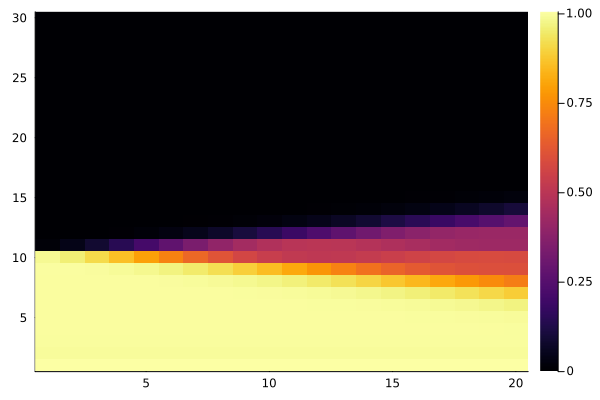

In [329]:
heatmap(stack([density(p) for p in run10.obs[:,"probs"]]))

In [328]:
density(run10.obs.probs)

20-element Vector{Matrix{Float64}}:
 [0.0 0.0 0.0 0.0; 0.0 0.0 0.0 0.0; … ; 0.0 0.0 0.0 0.0; 0.0 0.0 0.0 0.0]
 [0.0 0.0 0.0 0.0; 0.0 0.0 0.0 0.0; … ; 0.0 0.0 0.0 0.0; 0.0 0.0 0.0 0.0]
 [0.0 0.0 0.0 0.0; 0.0 0.0 0.0 0.0; … ; 0.0 0.0 0.0 0.0; 0.0 0.0 0.0 0.0]
 [0.0 0.0 0.0 0.0; 0.0 0.0 0.0 0.0; … ; 0.0 0.0 0.0 0.0; 0.0 0.0 0.0 0.0]
 [0.0 0.0 0.0 0.0; 0.0 0.0 0.0 0.0; … ; 0.0 0.0 0.0 0.0; 0.0 0.0 0.0 0.0]
 [0.0 0.0 0.0 0.0; 0.0 0.0 0.0 0.0; … ; 0.0 0.0 0.0 0.0; 0.0 0.0 0.0 0.0]
 [0.0 0.0 0.0 0.0; 0.0 0.0 0.0 0.0; … ; 0.0 0.0 0.0 0.0; 0.0 0.0 0.0 0.0]
 [0.0 0.0 0.0 0.0; 0.0 0.0 0.0 0.0; … ; 0.0 0.0 0.0 0.0; 0.0 0.0 0.0 0.0]
 [0.0 0.0 0.0 0.0; 0.0 0.0 0.0 0.0; … ; 0.0 0.0 0.0 0.0; 0.0 0.0 0.0 0.0]
 [0.0 0.0 0.0 0.0; 0.0 0.0 0.0 0.0; … ; 0.0 0.0 0.0 0.0; 0.0 0.0 0.0 0.0]
 [0.0 0.0 0.0 0.0; 0.0 0.0 0.0 0.0; … ; 0.0 0.0 0.0 0.0; 0.0 0.0 0.0 0.0]
 [0.0 0.0 0.0 0.0; 0.0 0.0 0.0 0.0; … ; 0.0 0.0 0.0 0.0; 0.0 0.0 0.0 0.0]
 [0.0 0.0 0.0 0.0; 0.0 0.0 0.0 0.0; … ; 0.0 0.0 0.0 0.0; 0.0 0.0 0.0 0.0]
 [

In [168]:
Hopping(30)

sum(
  -1.0 n(1,)
  -1.0 ad(1,) a(2,)
  -1.0 ad(2,) a(1,)
  -1.0 ad(2,) a(3,)
  -1.0 ad(3,) a(2,)
  -1.0 ad(3,) a(4,)
  -1.0 ad(4,) a(3,)
  -1.0 ad(4,) a(5,)
  -1.0 ad(5,) a(4,)
  -1.0 ad(5,) a(6,)
  -1.0 ad(6,) a(5,)
  -1.0 ad(6,) a(7,)
  -1.0 ad(7,) a(6,)
  -1.0 ad(7,) a(8,)
  -1.0 ad(8,) a(7,)
  -1.0 ad(8,) a(9,)
  -1.0 ad(9,) a(8,)
  -1.0 ad(9,) a(10,)
  -1.0 ad(10,) a(9,)
  -1.0 ad(10,) a(11,)
  -1.0 ad(11,) a(10,)
  -1.0 ad(11,) a(12,)
  -1.0 ad(12,) a(11,)
  -1.0 ad(12,) a(13,)
  -1.0 ad(13,) a(12,)
  -1.0 ad(13,) a(14,)
  -1.0 ad(14,) a(13,)
  -1.0 ad(14,) a(15,)
  -1.0 ad(15,) a(14,)
  -1.0 ad(15,) a(16,)
  -1.0 ad(16,) a(15,)
  -1.0 ad(16,) a(17,)
  -1.0 ad(17,) a(16,)
  -1.0 ad(17,) a(18,)
  -1.0 ad(18,) a(17,)
  -1.0 ad(18,) a(19,)
  -1.0 ad(19,) a(18,)
  -1.0 ad(19,) a(20,)
  -1.0 ad(20,) a(19,)
  -1.0 ad(20,) a(21,)
  -1.0 ad(21,) a(20,)
  -1.0 ad(21,) a(22,)
  -1.0 ad(22,) a(21,)
  -1.0 ad(22,) a(23,)
  -1.0 ad(23,) a(22,)
  -1.0 ad(23,) a(24,)
  -1.0 ad(24,) a(23,)
  -1

After sweep 1 energy=-15.691970159452655  maxlinkdim=16 maxerr=9.03E-07 time=0.082
After sweep 2 energy=-15.812053953052402  maxlinkdim=19 maxerr=9.20E-07 time=0.310
After sweep 3 energy=-15.819472112658229  maxlinkdim=16 maxerr=9.65E-07 time=0.305
After sweep 4 energy=-15.81969549106939  maxlinkdim=16 maxerr=9.82E-07 time=0.320
After sweep 5 energy=-15.819702991514712  maxlinkdim=17 maxerr=9.91E-07 time=0.294
After sweep 6 energy=-15.819703521505751  maxlinkdim=17 maxerr=8.67E-07 time=0.292
After sweep 7 energy=-15.819703545904783  maxlinkdim=17 maxerr=8.66E-07 time=0.292
Stopping DMRG after sweep 7
  1.910464 seconds (22.19 M allocations: 2.936 GiB, 9.73% gc time)


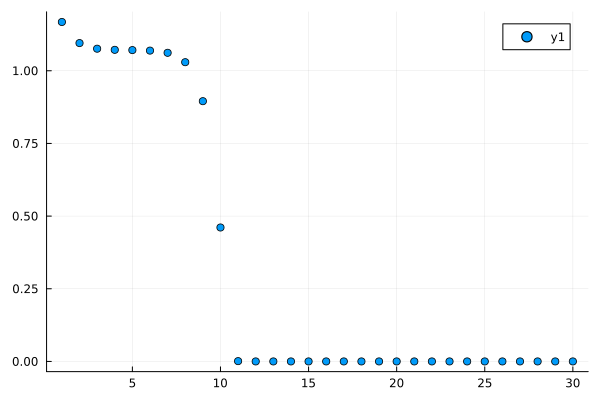

In [167]:
@time ghw1=findgs(10,well(30;V=20,L=10.5,s=0);t=1,U=1.,maxn=10,
    dmrgopts=(nsweeps=50,maxdim=100,cutoff=1E-6,outputlevel=1))
scatter(expect(ghw1.ψ,"n"))

# Validation

Lets validate the oscillating hopping by running the TDVP with an oscillating hopping, but no trap -- and monitor the number of doublons produced as a function of time -- essentially the spectroscopy that Pranjal has been working on.

In [33]:
function unifgs(num,Lx;t=1,U=0,maxn=2,etol=1e-8,
        dmrgopts=(nsweeps=100,maxdim=100,cutoff=1E-6,outputlevel=0))
    d=maxn+1
    ψ,sites=Grid1D(Lx; d, Pn=num)
    Hop=BoseHubbardModel(t, U, Lx)
    HMPO=MPO(Hop,sites)
    observer=EnergyObserver(etol)
    E,ψ=dmrg(HMPO,ψ;dmrgopts...,observer)
    return (;ψ,E,observer)
end

unifgs (generic function with 1 method)

In [34]:
function drive(ψ₀;g,dg=0,η,dη=0,ω=0,time_step,T,
    tdvpopts=(;updater=krylov_updater,
            updater_kwargs=(;tol=1e-8,eager=true),
            cutoff=1e-6,maxdim=200,
            nsite=2,outputlevel=1
            ))
    Lx=length(ψ₀)
    sites=siteinds(ψ₀)
    K=MPO(Hopping(Lx),sites)
    U=MPO(Interactions(Lx),sites)
    H=TimeDependentSum([t->-im*(g+dg*sin(ω*t)),t->-im*(η+dη*sin(ω*t))],[K,U])
    obs=p_observer()
    println("calling tdvp")
    ψ = tdvp(H,T,ψ₀;tdvpopts...,time_step,(step_observer!)=obs)
    return (;ψ,obs)
end     

drive (generic function with 1 method)

In [68]:
@time ugs0=unifgs(4,4;U=4,maxn=4);

  0.044735 seconds (412.10 k allocations: 60.957 MiB, 17.21% gc time)


In [69]:
ugs0.observer.energylist

4-element Vector{Float64}:
 -3.6308515085508564
 -3.633995838361143
 -3.6339967984435084
 -3.6339968057501046

In [70]:
@time ugs1=unifgs(4,4;U=10,maxn=4);

  0.023026 seconds (276.93 k allocations: 43.189 MiB)


In [71]:
function showprobs(ψ;cutoff=1e-3)
    p=probs(ψ)
    v=plot()
    for (j,vals) in enumerate(eachcol(p))
        if maximum(vals)<cutoff
            continue
        end
        scatter!(vals;label="$(j-1)")
    end
    v
end

showprobs (generic function with 1 method)

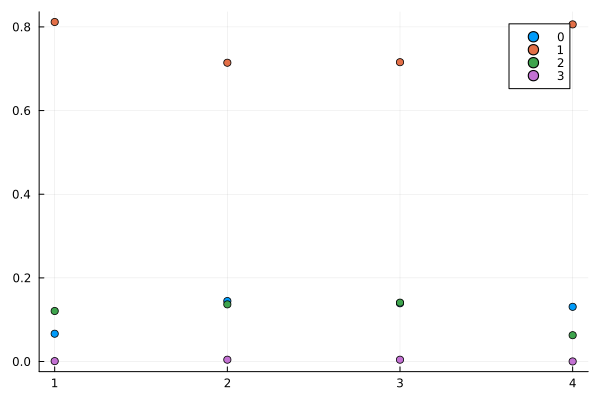

In [72]:
showprobs(ugs0.ψ)

In [73]:
probs(ugs0.ψ)

4×5 Matrix{Float64}:
 0.0664689  0.811756  0.120789   0.00098632   0.0
 0.144617   0.714336  0.136674   0.00435531   1.74938e-5
 0.139216   0.715639  0.140804   0.00433146   8.37988e-6
 0.130793   0.806036  0.0629363  0.000234721  0.0

In [74]:
@time dr0a=drive(ugs0.ψ;g=1,dg=0,η=4,dη=0,ω=4,
    time_step=0.1,T=2,
    tdvpopts=(;updater=krylov_updater,
            updater_kwargs=(;tol=1e-8,eager=true),
            cutoff=1e-6,maxdim=200,
            nsite=2,outputlevel=1
            ))

calling tdvp
After sweep 1: maxlinkdim=8 maxerr=3.93E-07 current_time=0.1 time=0.044
After sweep 2: maxlinkdim=8 maxerr=3.83E-07 current_time=0.2 time=0.03
After sweep 3: maxlinkdim=8 maxerr=3.87E-07 current_time=0.3 time=0.039
After sweep 4: maxlinkdim=8 maxerr=3.97E-07 current_time=0.4 time=0.036
After sweep 5: maxlinkdim=8 maxerr=3.97E-07 current_time=0.5 time=0.03
After sweep 6: maxlinkdim=8 maxerr=3.90E-07 current_time=0.6 time=0.038
After sweep 7: maxlinkdim=8 maxerr=3.89E-07 current_time=0.7 time=0.036
After sweep 8: maxlinkdim=8 maxerr=3.95E-07 current_time=0.8 time=0.03
After sweep 9: maxlinkdim=8 maxerr=3.97E-07 current_time=0.9 time=0.035
After sweep 10: maxlinkdim=8 maxerr=3.93E-07 current_time=1.0 time=0.036
After sweep 11: maxlinkdim=8 maxerr=3.88E-07 current_time=1.1 time=0.029
After sweep 12: maxlinkdim=8 maxerr=3.89E-07 current_time=1.2 time=0.036
After sweep 13: maxlinkdim=8 maxerr=3.93E-07 current_time=1.3 time=0.037
After sweep 14: maxlinkdim=8 maxerr=3.97E-07 curre

(ψ = MPS(4), obs = 20×3 DataFrame
 Row │ steps  times    probs                             
     │ Int64  Float64  Array…                            
─────┼───────────────────────────────────────────────────
   1 │     1      0.1  [0.0664688 0.811757 … 0.00098521…
   2 │     2      0.2  [0.0664685 0.811758 … 0.00098429…
   3 │     3      0.3  [0.0664681 0.811759 … 0.00098437…
   4 │     4      0.4  [0.0664675 0.81176 … 0.000985376…
   5 │     5      0.5  [0.0664668 0.811762 … 0.00098632…
   6 │     6      0.6  [0.0664653 0.811764 … 0.00098617…
   7 │     7      0.7  [0.0664631 0.811765 … 0.00098498…
   8 │     8      0.8  [0.0664626 0.811765 … 0.00098416…
   9 │     9      0.9  [0.066466 0.81176 … 0.000984903 …
  10 │    10      1.0  [0.0664722 0.811752 … 0.00098647…
  11 │    11      1.1  [0.0664764 0.811746 … 0.0009868 …
  12 │    12      1.2  [0.0664764 0.811745 … 0.00098517…
  13 │    13      1.3  [0.0664738 0.811748 … 0.00098364…
  14 │    14      1.4  [0.0664706 0.811754 … 0.0009

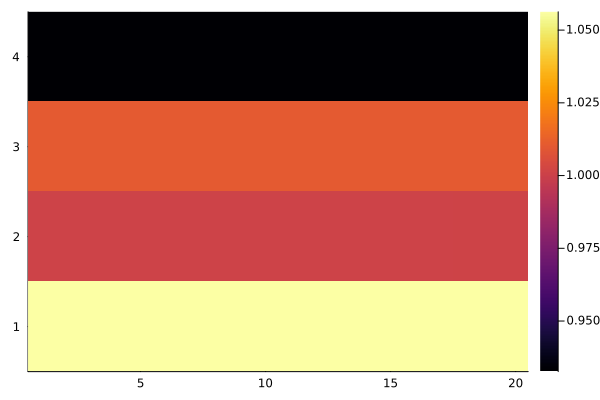

In [75]:
heatmap(stack([density(p) for p in dr0a.obs[:,"probs"]]))

In [76]:
doublons(probs)=[row[3] for row in eachrow(probs)]

doublons (generic function with 1 method)

In [92]:
nd(probs)=sum(doublons(probs))

nd (generic function with 1 method)

In [ ]:
doublons(probs)=[row[3] for row in eachrow(probs)]

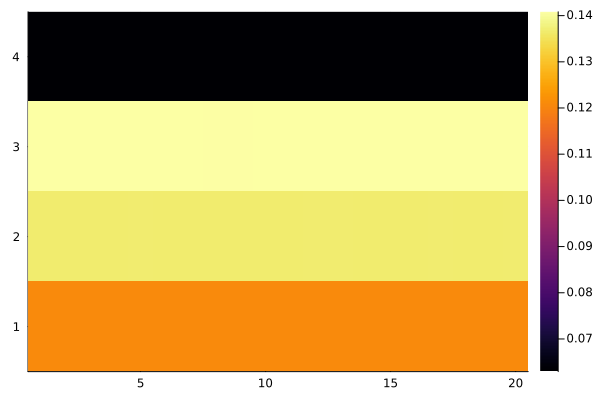

In [77]:
heatmap(stack([doublons(p) for p in dr0a.obs[:,"probs"]]))

In [66]:
round(2pi)

6.0

In [105]:
@time dr0b=drive(ugs0.ψ;g=1,dg=0.1,η=4,dη=0.05,ω=4,
    time_step=0.1,T=4*round(2*pi),
    tdvpopts=(;updater=krylov_updater,
            updater_kwargs=(;tol=1e-8,eager=true),
            cutoff=1e-6,maxdim=200,
            nsite=2,outputlevel=0
            ));

calling tdvp
 10.347465 seconds (156.87 M allocations: 20.879 GiB, 10.70% gc time)


In [88]:
sum(dr0b.obs[1,"probs"][:,3])

0.4601603273432757

In [93]:
nd(dr0b.obs[1,"probs"])

0.4601603273432757

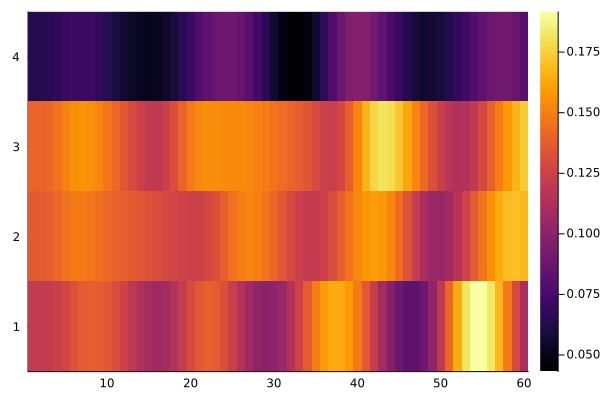

In [94]:
heatmap(stack([doublons(p) for p in dr0b.obs[:,"probs"]]))

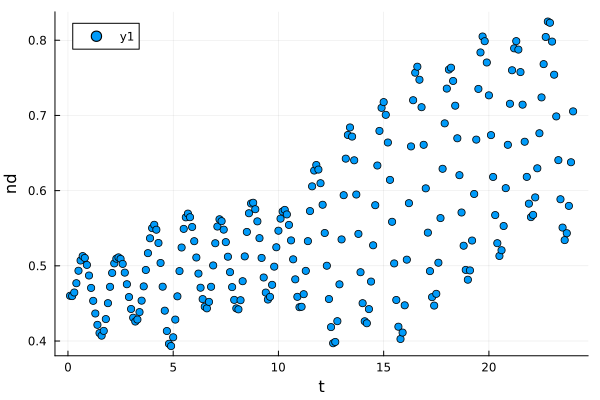

In [106]:
scatter(dr0b.obs[:,"times"],[nd(p) for p in dr0b.obs[:,"probs"]],xlabel="t",ylabel="nd")

In [104]:
@time dr0c=drive(ugs0.ψ;g=1,dg=0.1,η=4,dη=0.05,ω=1,
    time_step=0.1,T=4*round(2*pi),
    tdvpopts=(;updater=krylov_updater,
            updater_kwargs=(;tol=1e-8,eager=true),
            cutoff=1e-6,maxdim=200,
            nsite=2,outputlevel=0
            ));

calling tdvp
  9.268693 seconds (135.98 M allocations: 18.085 GiB, 10.61% gc time)


In [108]:
@time dr0d=drive(ugs0.ψ;g=1,dg=0.1,η=4,dη=0.05,ω=16,
    time_step=0.1,T=4*round(2*pi),
    tdvpopts=(;updater=krylov_updater,
            updater_kwargs=(;tol=1e-8,eager=true),
            cutoff=1e-6,maxdim=200,
            nsite=2,outputlevel=0
            ));

calling tdvp
 11.614817 seconds (162.72 M allocations: 21.930 GiB, 13.44% gc time)


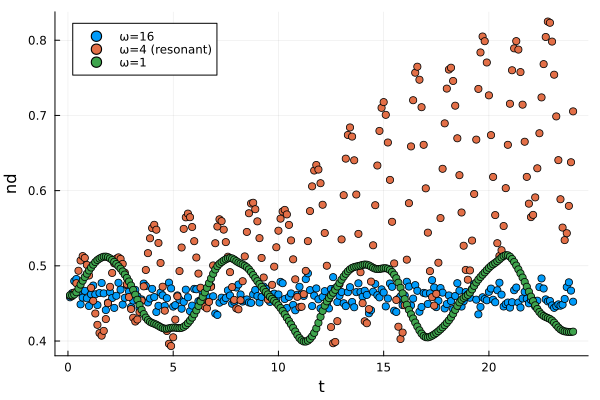

In [112]:
scatter(dr0d.obs[:,"times"],[nd(p) for p in dr0d.obs[:,"probs"]],
    xlabel="t",ylabel="nd",label="ω=16")
scatter!(dr0b.obs[:,"times"],[nd(p) for p in dr0b.obs[:,"probs"]],
    xlabel="t",ylabel="nd",label="ω=4 (resonant)")
scatter!(dr0c.obs[:,"times"],[nd(p) for p in dr0c.obs[:,"probs"]],
    xlabel="t",ylabel="nd",label="ω=1")


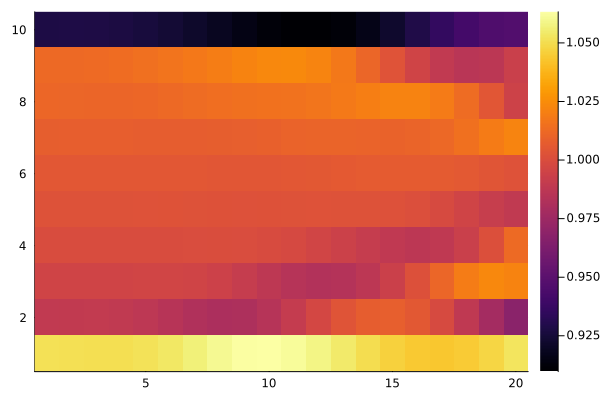

In [64]:
heatmap(stack([density(p) for p in dr0b.obs[:,"probs"]]))